# analyse base Rystad puis premiers modèles Julia/Pytorch



dataset très lourds, quelques astuces: nrows, usecols=[''], charger des string en category, nombres en float32 si la précision n'est pas requise encore, avec dtype={'Production':'float32'} 

chunk_iterator = pd.read_csv('.../Production.csv', chunksize=10000)
for chunk in chunk_iterator:
    # Traitement vectorisé sur le chunk (ex: agrégation, filtrage)
    pass


Migrer sur Polars pour le multithreading?

#### problèmes (réglés): 
* clés RE_ID en doublons ? 
* problèmes de décimales ',' et '.', séparation ; ou , 

In [16]:
import pandas as pd, numpy as np
from pathlib import Path

DATA = Path("/Users/rratajczyk/Desktop/OilMarket/local/Data")

Oil_Definition = ["Bitumen","Extra Heavy Oil","Heavy Oil 15-19",
                  "Heavy Oil 20-22","Sour (> 3%)","Regular","Light","Condensate","Synthetic crude"]#,"NGL"]# pourquoi NGL est dans Oil_Definition ? c'est du gaz, pas du pétrole. Et synthetic crude: double comptage avec bitumen, produit secondaire du traitement du bitume. (à voir la définition dans Rystad)
Gas_Definition = ["Gas","LNG","Feed gas to LNG","Feed gas to Pipeline","Gas in Pipelines","GTL"]

def to_num(s):
    # dans les colonnes numériques la virgule est toujours décimale, et aucun séparateur de milliers 
    return pd.to_numeric(s.astype(str).str.replace(",", ".", regex=False),
                         errors="coerce").round(6)

def load(name, numeric_cols=()):
    df = pd.read_csv(DATA / name, encoding="latin-1", low_memory=False)
    for c in numeric_cols:
        if c in df.columns:
            df[c] = to_num(df[c])
    return df

eco_cols = ["Free Cash Flow","Royalty effects","Income Tax","Well Capex","Facility Capex",
            "Exploration Well Capex","G&G and Seismic capex","SG&A Opex","Transportation Opex",
            "Production Opex","Abandonment cost","Sum","Government Profit Oil","Lease Capex","Taxes Opex"]
res_cols = ["Resources (Million bbl)","1P Reserves (Million bbl)",
            "2P Reserves (Million bbl)","Technical recoverable resources (Million bbl)"]

asset    = load("Asset_Info.csv").drop_duplicates("RE ID")
prod     = load("Production.csv", ["Production (Million bbl)"])
reserves = pd.concat([load("Reserves_North_America.csv", res_cols),
                      load("Reserves_Rest.csv",          res_cols)], ignore_index=True)
eco      = pd.concat([load("Eco_North_America.csv", eco_cols),
                      load("Eco_Rest.csv",          eco_cols)], ignore_index=True)
deflator = load("Deflator.csv", ["Economics (MUSD)","Economics (MUSD real)"])
ci       = pd.read_csv(DATA / "CI_Full.csv", low_memory=False)   # déjà UTF-8

for nm, d in [("asset",asset),("prod",prod),("reserves",reserves),
              ("eco",eco),("deflator",deflator),("ci",ci)]:
    print(f"{nm:9s} {d.shape}")





asset     (103193, 82)
prod      (8546951, 8)
reserves  (27581380, 8)
eco       (10557390, 19)
deflator  (201, 3)
ci        (57217, 25)


### voir : Figure 1: Heterogeneity in upstream and midstream carbon intensities. , Coulomb et al.
(a) Carbon-intensity-based oil supply: as of 1992
Oil type
Bitumen
60
Carbon intensity (gCO2e/MJ)
40
Condensate
Extra Heavy Oil
Heavy Oil 15−19
Heavy Oil 20−23
Light
Regular
Sour (> 3%)

In [17]:
prod.columns

Index(['RE ID', 'Asset', 'Year', 'Oil and Gas Detail', 'Data Type',
       'Data Confidence', 'Data Source', 'Production (Million bbl)'],
      dtype='str')

In [18]:
reserves['Oil and Gas Detail'].value_counts()

Oil and Gas Detail
Gas                     8658599
NGL                     5460632
Regular                 5173677
Condensate              4405232
Light                   3306642
Heavy Oil 15-19          134546
Sour (> 3%)              123826
Heavy Oil 20-22          106821
Extra Heavy Oil           61463
Bitumen                   60033
Feed gas to LNG           39509
LNG                       39509
Synthetic crude            6462
CTG                        3337
GTL                         848
Gas in Pipelines            122
Feed gas to Pipeline        122
Name: count, dtype: int64

In [19]:
COULOMB_T3 = {"Saudi Arabia":14,"Russia":12,"United States":10,"Iran":5,"China":5,
              "Mexico":4,"UAE":4,"Canada":4,"Venezuela":4,"Iraq":3,"Norway":3,
              "Kuwait":3,"Nigeria":3,"United Kingdom":2,"Brazil":2}

p = prod.copy()
p = p[p["Oil and Gas Detail"] != "Sum"]
p = p[~p["Asset"].str.contains("ther liquids|Refinery gains", na=False)]
p = p[(p["Year"] >= 1992) & (p["Year"] <= 2018)]
p = p[p["Oil and Gas Detail"].isin(Oil_Definition)]

p = p.merge(asset[["RE ID","Country"]], on="RE ID", how="left")
p["Country"] = p["Country"].replace({"Lybia":"Libya"})        # faute Rystad

# Neutral Zone -> 50/50 Saudi Arabia / Kuwait
nz = p[p["Country"] == "Neutral Zone"].copy(); nz["Production (Million bbl)"] /= 2
p = pd.concat([p[p["Country"] != "Neutral Zone"],
               nz.assign(Country="Saudi Arabia"), nz.assign(Country="Kuwait")])

ctry = p.groupby("Country")["Production (Million bbl)"].sum()
share = (100 * ctry / ctry.sum()).round(1).sort_values(ascending=False)

cmp3 = (share.rename("nous").to_frame()
        .assign(Coulomb=lambda d: d.index.map(COULOMB_T3)))
print("TOP 15 PRODUCTION:\n", cmp3.head(15))

# écart  moyen à la table de Coulomb 
print(f"Écart moyen absolu (MAPE) : {(((cmp3.head(15)['nous'] - cmp3.head(15)['Coulomb']).abs() / cmp3.head(15)['Coulomb']).mean() * 100).round(2)} %")

TOP 15 PRODUCTION:
                 nous  Coulomb
Country                      
Saudi Arabia    12.6     14.0
Russia          12.1     12.0
United States    9.2     10.0
Iran             5.3      5.0
China            4.9      5.0
Venezuela        4.0      4.0
Mexico           3.9      4.0
Canada           3.6      4.0
UAE              3.6      4.0
Norway           3.3      3.0
Iraq             3.2      3.0
Kuwait           3.2      3.0
Nigeria          3.0      3.0
United Kingdom   2.3      2.0
Brazil           2.2      2.0
Écart moyen absolu (MAPE) : 6.51 %


## méthode de calcul: 

## $S_i = \frac{\sum_{t=1992}^{2018} q_{i,t}}{\sum_{t=1992}^{2018} Q_t}$
(notations q ou x pour l'extraction)

In [20]:
COULOMB_T5 = {"Saudi Arabia":286,"Russia":143,"United States":190,"Iran":90,"China":46,
              "Mexico":25,"UAE":72,"Canada":101,"Venezuela":34,"Iraq":122,"Norway":21,
              "Kuwait":61,"Nigeria":26,"United Kingdom":13,"Brazil":62}

r = reserves.rename(columns={"Resources (Million bbl)":"Resources",
                             "1P Reserves (Million bbl)":"Reserves_1P",
                             "2P Reserves (Million bbl)":"Reserves_2P"})
r["Oil_Gas"] = np.where(r["Oil and Gas Detail"].isin(Oil_Definition), "Oil",
               np.where(r["Oil and Gas Detail"].isin(Gas_Definition), "Gas", "Other"))
r = r[(r["Oil_Gas"] == "Oil") & (r["Year"] == 2019)]
r = (r.groupby("RE ID", as_index=False)[["Resources","Reserves_1P","Reserves_2P"]].sum()
       .merge(asset[["RE ID","Country"]], on="RE ID", how="left"))
r["Country"] = r["Country"].replace({"Lybia":"Libya"})

nz = r[r["Country"] == "Neutral Zone"].copy()
for c in ["Resources","Reserves_1P","Reserves_2P"]: nz[c] /= 2
r = pd.concat([r[r["Country"] != "Neutral Zone"],
               nz.assign(Country="Saudi Arabia"), nz.assign(Country="Kuwait")])

out = r.groupby("Country")[["Resources","Reserves_1P","Reserves_2P"]].sum() / 1000  # -> Gb
out = out.assign(Coulomb_Resources=lambda d: d.index.map(COULOMB_T5))
print("Total monde Resources (Gb) :", round(out["Resources"].sum(), 0), " (papier ≈1518)")
print(out.loc[list(COULOMB_T5)].round(0))

Total monde Resources (Gb) : 1424.0  (papier ≈1518)
                Resources  Reserves_1P  Reserves_2P  Coulomb_Resources
Country                                                               
Saudi Arabia        245.0         56.0         90.0              286.0
Russia              141.0         49.0         76.0              143.0
United States       124.0         44.0         59.0              190.0
Iran                 91.0         16.0         30.0               90.0
China                63.0         18.0         36.0               46.0
Mexico               19.0          5.0         10.0               25.0
UAE                  76.0         18.0         32.0               72.0
Canada               87.0         37.0         56.0              101.0
Venezuela            13.0          3.0          5.0               34.0
Iraq                109.0         20.0         46.0              122.0
Norway               16.0          5.0         10.0               21.0
Kuwait               50.0

### $2P = 1P + Probable$
Pandas effectue une agrégation verticale, donc on ne mélange jamais 2P avec 1P avec Reserves par ex (jamais de double comptage). 


Coulomb et al. définissent les réserves de 2019 en sommant la trajectoire d'extraction future prévue par Rystad dans son scénario par défaut (BAU), d'aujourd'hui jusqu'en 2100.
Mathématiquement : $R_{i, 2019} = \sum_{t=2019}^{2100} q_{i,t}^{BAU}$.
Cette définition exclut alors "les ressources qui ne devraient jamais être économiquement ou techniquement récupérables"  

Je cite:   
"A country’s stranded assets are expressed as the share of its 2019 recoverable reserves
that is left underground under a specific scenario. For each field (discovered before 2019),
we compute its 2019 oil reserves as the sum of its future productions up to 2100 based on
Rystad business-as-usual (BAU) scenario, as done in the rest of the paper (see Appendices
D.1 and D.2). This reserve measure thus excludes resources that are never expected to be
economically or technically recoverable. The “stranded assets” can thus be interpreted as
the assets that become unburnable due to mitigation policy (here the joint effect of demand
drop in the future compared to a BAU and supply recomposition).20 The last column of
20The amount of oil underground exceeds the proven reserves in our analysis. But oil resources not
26
Table 5 gives the 2019 reserves by country, and global reserves of about 1,518 Gb. Overall,
our global reserves estimates are on par with those of the rest of the literature (BP, 2019;
IEA, 2019; OPEC, 2019; BGR, 2020; EIA, 2021; Welsby et al., 2021) with an average value
of 1,598 Gb, a maximum of 1,790 Gb (BGR, 2020) and a minimum of 1,276 Gb (Welsby
et al., 2021)."  

$R_{i, 2019} = \sum_{t=2019}^{2100} q_{i,t}^{BAU}$





In [21]:

print(prod['Data Type'].value_counts())
print(prod['Data Source'].value_counts())
print(prod['Year'].value_counts())


Data Type
Modeled          5580748
Sum              1993462
Researched        972733
Not Available          8
Name: count, dtype: int64
Data Source
Modeled                        5580748
Sum                            1993544
Government webpage              675269
Analyst estimate                146704
Annual Report                    60105
Other document                   53314
Company Press Releases           20213
Articles on oil&gas domains      11121
Investor Presentation             5864
Company Webpage                     46
Oilfield service Report             15
Not Available                        8
Name: count, dtype: int64
Year
2055    124954
2056    124908
2054    124666
2057    124546
2053    123909
         ...  
1904       696
1903       685
1902       632
1901       611
1900       569
Name: count, Length: 201, dtype: int64


In [22]:

p = prod[(prod["Oil and Gas Detail"].isin(Oil_Definition)) & (prod["Data Type"] != "Sum")].copy()

# CAPACITÉ : Pic historique par gisement
capa_asset = p.groupby("RE ID")["Production (Million bbl)"].max().rename("Capacity")

#  RÉSERVES BAU  : Intégrale de la production future (2019-2100) (Coulomb)
res_bau = p[p["Year"] >= 2019].groupby("RE ID")["Production (Million bbl)"].sum().rename("Reserves BAU (Million bbl)")

# Méthode STATIQUE : agrégation 2019 
r = reserves[(reserves["Oil and Gas Detail"].isin(Oil_Definition)) & (reserves["Year"] == 2019)]
cols_res = ["1P Reserves (Million bbl)", "2P Reserves (Million bbl)", "Technical recoverable resources (Million bbl)"]
res_asset = r.groupby("RE ID")[cols_res].sum()


df_assets = (res_asset
             .join(capa_asset, how="outer")
             .join(res_bau, how="outer")
             .merge(asset[["RE ID", "Country"]], on="RE ID", how="left"))

# ZONE NEUTRE (50/50)
cols_to_split = cols_res + ["Capacity", "Reserves BAU (Million bbl)"]
nz = df_assets[df_assets["Country"] == "Neutral Zone"].copy()
nz[cols_to_split] /= 2

df_assets = pd.concat([
    df_assets[df_assets["Country"] != "Neutral Zone"], 
    nz.assign(Country="Saudi Arabia"), 
    nz.assign(Country="Kuwait")
])

# Agregagatio, par pays. 
tableau_final = df_assets.groupby("Country")[cols_to_split].sum().round(2)


print(tableau_final.sort_values("Reserves BAU (Million bbl)", ascending=False).head(15))

print("Total monde Reserves BAU (Gb) :", round(tableau_final["Reserves BAU (Million bbl)"].sum() / 1000, 2), " (papier ≈1518)")

               1P Reserves (Million bbl)  2P Reserves (Million bbl)  \
Country                                                               
Saudi Arabia                    55538.82                   89728.73   
United States                   44439.41                   58670.32   
Russia                          49167.95                   75513.69   
Iraq                            19858.63                   46124.96   
Canada                          36695.55                   55521.50   
Iran                            16493.02                   30029.66   
UAE                             18315.32                   31742.79   
China                           18397.05                   35850.11   
Kuwait                          12722.02                   20826.93   
Brazil                          10446.61                   29408.76   
Kazakhstan                      14507.78                   18520.96   
Qatar                            8638.96                   15163.44   
Argent

1. La base n'exporte pas l'agrégat strict "3P". La variable Technical recoverable resources est utilisée comme proxy de la borne supérieure absolue des volumes récupérables (incluant les ressources contingentes).
2. La capacité est modélisée comme la somme des pics de production historiques des gisements du pays.

In [23]:
import matplotlib.pyplot as plt

# pour les déciles de la Figure 1b
def wquantile(values, weights, q):
    v = np.asarray(values, float); w = np.asarray(weights, float)
    m = np.isfinite(v) & np.isfinite(w) & (w > 0); v, w = v[m], w[m]
    if len(v) == 0: return np.nan
    o = np.argsort(v); v, w = v[o], w[o]
    cum = (np.cumsum(w) - 0.5*w) / w.sum()
    return np.interp(q, cum, v)

# prod_w : production oil par champ sur 1992-2018 (= poids des moyennes/déciles) 
prod_w = (prod[prod["Year"].between(1992, 2018) & prod["Oil and Gas Detail"].isin(Oil_Definition)]
          .groupby("RE ID", as_index=False)["Production (Million bbl)"].sum()
          .rename(columns={"Production (Million bbl)": "prod_w"}))

print("prod_w :", prod_w.shape, "| wquantile OK")

prod_w : (22524, 2) | wquantile OK


In [24]:
# Costs_Included = Unit_Param$Costs_Included.  "coûts réels privés" (opex + capex + abandon),
# fiscalité (Royalty/Income Tax/Gvt Profit/Taxes Opex) exclue (transferts)
Costs_Included = ["Production Opex","Transportation Opex","SG&A Opex",
                  "Well Capex","Facility Capex","Exploration Well Capex",
                  "G&G and Seismic capex","Abandonment cost"]

deflator["Deflate_factor"] = deflator["Economics (MUSD real)"] / deflator["Economics (MUSD)"]
e = eco.merge(deflator[["Year","Deflate_factor"]], on="Year", how="left")
e["Deflate_factor"] = e["Deflate_factor"].fillna(1.0)
for c in Costs_Included:
    e[c] = e[c] * e["Deflate_factor"]               #  USD réels déflatés
e["cost_year"] = e[Costs_Included].sum(axis=1)

cost_tot = e.groupby("RE ID")["cost_year"].sum()
oil_tot  = (prod[prod["Oil and Gas Detail"].isin(Oil_Definition)]
            .groupby("RE ID")["Production (Million bbl)"].sum())
cost = (cost_tot / oil_tot).rename("cost_bbl").reset_index()   #  "Average" = sum(coûts)/sum(prod)
cost = cost.replace([np.inf, -np.inf], np.nan).dropna()
if cost["cost_bbl"].median() < 0:                   
    cost["cost_bbl"] = -cost["cost_bbl"]
print(cost["cost_bbl"].describe().round(2))

count    5.278700e+04
mean     6.707513e+17
std      1.541079e+20
min     -1.072152e+09
25%      4.204000e+01
50%      9.398000e+01
75%      2.866600e+02
max      3.540695e+22
Name: cost_bbl, dtype: float64


In [25]:
print(" signe/magnitude des colonnes de coût (eco) ")
print(eco[Costs_Included].describe().T[["mean","50%","min","max"]].round(2))

oil_tot = (prod[prod["Oil and Gas Detail"].isin(Oil_Definition)]
           .groupby("RE ID")["Production (Million bbl)"].sum())
print("\nchamps oil_tot < 0.1 Mbbl :", int((oil_tot < 0.1).sum()), "/", len(oil_tot))

cic = (ci["CI_Final_EBA"] + ci["CI_midstream"])
print("\nCI combinée (kg/bbl) :", cic.describe().round(1).to_dict())

print("\nVenezuela - asset:", int((asset['Country']=='Venezuela').sum()),
      "| ci:", int((ci['Country']=='Venezuela').sum()))

 signe/magnitude des colonnes de coût (eco) 
                         mean   50%  min        max
Production Opex          5.51  0.04 -0.0   17569.51
Transportation Opex      3.19  0.02 -0.0   11178.16
SG&A Opex                3.05  0.02 -0.0   10468.30
Well Capex              29.56  0.17 -0.0  122579.50
Facility Capex          11.75  0.15 -0.0   46990.64
Exploration Well Capex   7.02  0.00 -0.0    2927.00
G&G and Seismic capex    0.45  0.04  0.0    2361.26
Abandonment cost         1.70  0.00 -0.0    9503.23

champs oil_tot < 0.1 Mbbl : 18295 / 58800

CI combinée (kg/bbl) : {'count': 57217.0, 'mean': 139.9, 'std': 3528.6, 'min': 46.5, '25%': 62.8, '50%': 70.1, '75%': 82.3, 'max': 627771.9}

Venezuela - asset: 667 | ci: 527


In [26]:
Costs_Included = ["Production Opex","Transportation Opex","SG&A Opex",
                  "Well Capex","Facility Capex","Exploration Well Capex",
                  "G&G and Seismic capex","Abandonment cost"]

deflator["Deflate_factor"] = deflator["Economics (MUSD real)"] / deflator["Economics (MUSD)"]
e = eco.merge(deflator[["Year","Deflate_factor"]], on="Year", how="left")
e["Deflate_factor"] = e["Deflate_factor"].fillna(1.0)
e[Costs_Included] = e[Costs_Included].fillna(0)
for c in Costs_Included:
    e[c] = e[c] * e["Deflate_factor"]
cost_tot = e.groupby("RE ID")[Costs_Included].sum().sum(axis=1)

g = prod[prod["Oil and Gas Detail"].isin(Oil_Definition + Gas_Definition)].copy()
g["is_oil"] = g["Oil and Gas Detail"].isin(Oil_Definition)
tot  = g.groupby("RE ID")["Production (Million bbl)"].sum()
oilp = g[g["is_oil"]].groupby("RE ID")["Production (Million bbl)"].sum()

cost = pd.DataFrame({"cost_tot": cost_tot}).join(tot.rename("tot")).join(oilp.rename("oil_tot"))
cost = cost[cost["oil_tot"].fillna(0) >= 0.1]            # vire les champs ~sans oil (division explosive)
cost["cost_bbl"] = cost["cost_tot"] / cost["tot"]        # coûts / production totale (boe) = part oil imputée
cost = cost.replace([np.inf,-np.inf], np.nan).dropna(subset=["cost_bbl"]).reset_index()
print(cost["cost_bbl"].describe().round(2))

count    40495.00
mean        63.83
std        341.40
min          2.05
25%         22.65
50%         33.81
75%         54.44
max      21339.20
Name: cost_bbl, dtype: float64


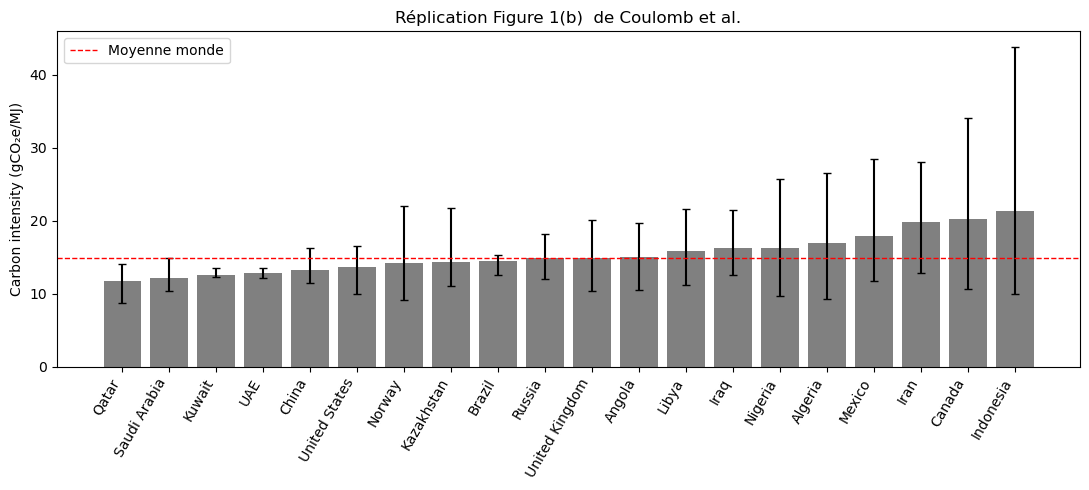

In [27]:
ci2 = ci.rename(columns={"REID":"RE ID"})
UP, MID = "CI_Final_EBA", "CI_midstream"
MJ_PER_BBL = 6120.0

d = (ci2[["RE ID", UP, MID]].dropna()
     .assign(CI_comb=lambda x: x[UP] + x[MID])
     .merge(asset[["RE ID","Country"]], on="RE ID", how="left")
     .merge(prod_w, on="RE ID", how="left"))
d = d[d["CI_comb"] < 300]                         # CI extrêmes 
d["Country"] = d["Country"].replace({"Lybia":"Libya"})
d = d.dropna(subset=["Country","prod_w"]); d = d[d["prod_w"] > 0]
d = d[d["Country"].isin(d.groupby("Country")["prod_w"].sum().nlargest(20).index)]

def agg(g):
    k = 1000/MJ_PER_BBL
    return pd.Series({"mean": np.average(g["CI_comb"], weights=g["prod_w"])*k,
                      "p10": wquantile(g["CI_comb"], g["prod_w"], .10)*k,
                      "p90": wquantile(g["CI_comb"], g["prod_w"], .90)*k})
bars = d.groupby("Country").apply(agg, include_groups=False).sort_values("mean")

lower = (bars["mean"] - bars["p10"]).clip(lower=0)   
upper = (bars["p90"] - bars["mean"]).clip(lower=0)

fig, ax = plt.subplots(figsize=(11,5))
ax.bar(bars.index, bars["mean"], color="grey")
ax.errorbar(bars.index, bars["mean"], yerr=[lower, upper],
            fmt="none", ecolor="black", capsize=3)
ax.axhline(np.average(d["CI_comb"], weights=d["prod_w"])*1000/MJ_PER_BBL,
           color="red", ls="--", lw=1, label="Moyenne monde")
ax.set_ylabel("Carbon intensity (gCO₂e/MJ)")
ax.set_title("Réplication Figure 1(b)  de Coulomb et al.")
plt.xticks(rotation=60, ha="right"); ax.legend(); plt.tight_layout(); plt.show()

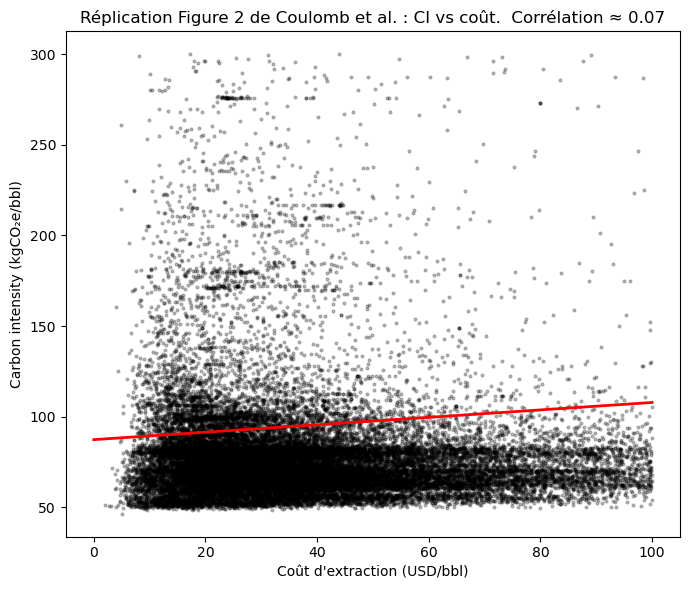

In [28]:
d2 = (ci2[["RE ID", UP, MID]].dropna()
      .assign(CI_comb=lambda x: x[UP] + x[MID])      # kgCO2e/bbl
      .merge(cost, on="RE ID", how="inner")
      .merge(prod_w, on="RE ID", how="left"))
d2 = d2[(d2["CI_comb"] < 300) & d2["cost_bbl"].between(0,100)].dropna(subset=["CI_comb","cost_bbl"])

w = d2["prod_w"].fillna(0).clip(lower=0).to_numpy() + 1e-9
C = np.cov(np.vstack([d2["cost_bbl"], d2["CI_comb"]]), aweights=w)
corr = C[0,1] / np.sqrt(C[0,0]*C[1,1])
b, a = np.polyfit(d2["cost_bbl"], d2["CI_comb"], 1, w=np.sqrt(w))

fig, ax = plt.subplots(figsize=(7,6))
ax.scatter(d2["cost_bbl"], d2["CI_comb"], s=4, alpha=.25, color="black")
xs = np.linspace(0,100,50); ax.plot(xs, b*xs+a, "r-", lw=2)
ax.set_xlabel("Coût d'extraction (USD/bbl)")
ax.set_ylabel("Carbon intensity (kgCO₂e/bbl)")
ax.set_title(f"Réplication Figure 2 de Coulomb et al. : CI vs coût.  Corrélation ≈ {corr:.2f}")
plt.tight_layout(); plt.show()

In [29]:
import pandas as pd 
import numpy as np 

df_asset_info = pd.read_csv('/Users/rratajczyk/Desktop/OilMarket/repo/Data/Asset_Info.csv', encoding='Latin-1',nrows=1000)
df_reserves_NA = pd.read_csv('/Users/rratajczyk/Desktop/OilMarket/repo/Data/Reserves_North_America.csv',  encoding='Latin-1',nrows=1000)
df_reserves_rest = pd.read_csv('/Users/rratajczyk/Desktop/OilMarket/repo/Data/Reserves_Rest.csv', encoding='Latin-1',nrows=1000)
df_production = pd.read_csv('/Users/rratajczyk/Desktop/OilMarket/repo/Data/Production.csv',  encoding='Latin-1',nrows=1000)
df_eco_NA = pd.read_csv('/Users/rratajczyk/Desktop/OilMarket/repo/Data/Eco_North_America.csv',  encoding='Latin-1',nrows=1000)
df_eco_rest = pd.read_csv('/Users/rratajczyk/Desktop/OilMarket/repo/Data/Eco_Rest.csv',  encoding='Latin-1',nrows=1000)
df_Deflator = pd.read_csv('/Users/rratajczyk/Desktop/OilMarket/repo/Data/Deflator.csv',  encoding='Latin-1',nrows=1000)
df_Carbon_Intensity = pd.read_csv('/Users/rratajczyk/Desktop/OilMarket/repo/Data/CI_Full.csv',  encoding='Latin-1',nrows=1000)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/rratajczyk/Desktop/OilMarket/repo/Data/Asset_Info.csv'

In [ ]:

print(f"NaN = {df_reserves_rest['Resources (Million bbl)'].isna().sum() / len(df_reserves_rest['Resources (Million bbl)']) * 100:.2f}%")

LoadError: LoadError: UndefVarError: `@f_str` not defined in `Main`
Suggestion: check for spelling errors or missing imports.
in expression starting at /Users/rratajczyk/Desktop/OilMarket/repo/code_oil/python/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X32sZmlsZQ==.jl:2

In [ ]:
df_asset_info.columns

df_reserves_NA.columns

df_production.columns

df_eco_NA.columns 
# CapEx (coût d'investissement dans les infrastructures) et OpEx (coût opératoire d'exploitation) , 
# fiscalité (Royalties=rente à verser à l'Etat, taxe sur la production) et break-even prices (revenue=coût)

#df_Deflator.columns # pour convertir en dollars constants, avec base 2XXX (?)

# redondant avec reserves_NA #df_reserves_rest.columns
# redondant avec eco_NA #df_eco_rest.columns
# méga-gisements au Moyen-Orient versus nombre démesurés de gisements différents aux US, d'où la séparation NA / reste du monde 

UndefVarError: UndefVarError: `df_asset_info` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
path = '/Users/rratajczyk/Desktop/OilMarket/repo/Data/'
datasets= ['Asset_Info.csv', 'Reserves_North_America.csv', 'Reserves_Rest.csv', 'Production.csv', 'Eco_North_America.csv', 'Eco_Rest.csv', 'Deflator.csv']
for p in datasets: 
    print(f"#### {p} ####")
    df = pd.read_csv(f'/Users/rratajczyk/Desktop/OilMarket/repo/Data/{p}',nrows=1000)
    print(df.dtypes)
    print(df.columns)
    print(df.head(2))


Base.Meta.ParseError: ParseError:
# Error @ /Users/rratajczyk/Desktop/OilMarket/repo/code_oil/python/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X35sZmlsZQ==.jl:1:9
path = '/Users/rratajczyk/Desktop/OilMarket/repo/Data/'
#       └────────────────────────────────────────────┘ ── character literal contains multiple characters

In [ ]:
# # clé commune : RE_ID (+Year pour les données de panel)
# df_main = pd.merge(df_prod, df_eco, on=['RE ID', 'Year'], how='inner')

# df_main = pd.merge(df_main, df_asset, on='RE ID', how='left') # peut créer des NaN pour les gisements présents dans prod/eco mais absents de asset_info, à vérifier
# df_main2 = pd.merge(df_main,df_asset,on='RE ID', how='inner') 
# print(df_main.shape, df_main2.shape) 

Base.Meta.ParseError: ParseError:
# Error @ /Users/rratajczyk/Desktop/OilMarket/repo/code_oil/python/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X36sZmlsZQ==.jl:2:42
# clé commune : RE_ID (+Year pour les données de panel)
df_main = pd.merge(df_prod, df_eco, on=['RE ID', 'Year'], how='inner')
#                                        └───┘ ── character literal contains multiple characters



### notes Code Modele_V2 Léo 

minimise coûts d'extraction + coût carbone taxé + coûts d'investissement − surplus du consommateur sur tout champ i et tout temps t ; contraintes réserves avec taux de déclin, capacité-plateau proportionnelle au niveau de développement (avec délai LAD entre investissement et production, et dépréciation du capital), niveau de développement borné, demande iso-élastique (élasticité croissant de 0,1 à 0,6), année de découverte.


Pas joueur stratégique, pas de theta, pas de cartel, pas de coalition .
avec la taxe = SCC, Léo donne l'optimum social
Il répond à la question que se passe-t-il si la cartellisation est empêchée ? c'est un équilibre concurrentiel, c'est le noeud entièrement décartellisé de notre DAG ?

# julia

Pas des optimisations: des recherches de points fixes de best-responses functions, c'est différent. 
Objectif: valider un solver, on utilise des données jouet, rien de réel.

Rystad entre quand on veut produire des résultats sur le marché du pétrole, mais il faut déjà valider les modèles sur des données rondes faciles à vérifier. Rystad entre en jeu pour un changement d'objectif (production), pas un ajout de couche de compelxité


## Modèle 0

Equilibre de Nash-Cournot STATIQUE (1 periode) : cartel vs frange agregée, avec parametre de collusion theta dans [0,1] (ad-hoc mais peut se microfonder).


ce code: 
C'est UN noeud du DAG, sans coalition, avec 1 periode. Nash-Cournot (pas Stackelberg) : le cartel prend l'offre de la frange comme DONNEE (a son niveau d'equilibre), sans anticiper sa reaction marginale d qf / d qc. Ce terme de reaction = ce qu'ajoute Stackelberg ; il est absent ici, voulu.
theta parametre de collusion exogène, posé au niveau du bloc cartel (comme De Canniere, qui l'assume comme ça, et cite
Reiss et Wolak). 
theta=0 : concurrence ; theta=1 : cartel pur / monopole.
Ici theta est POSé, pas derivé. Sa micro-fondation comme degre de
cooperation phi (Cyert et DeGroot 1973), via theta=(1+phi(N-1))/N, vit dans
le Modele 0' (N joueurs) ; son endogeneisation arrive avec le DAG ?. Dans cette cellule on considère un seul bloc, phi n'a aucun role

Pas encore besoin de Gurobi

FOC cartel : $$p − \theta \beta q^c − c^c = 0$$
Offre frange (price-taker) : $$q^f = (p − c^f)/\gamma^f$$
Demande:
$$p = \alpha − \beta(q^c + q^f).$$

Soluble exactement (avec la forme ad-hoc de theta, mais qui peut se microfonder)
-> le modèle 0 est "parfait" *pour ce qui compte pour lui*: il est exact, minimal, honnête

Le code résout deux fois : par substitution analytique (référence exacte, avec les deux coins KKT : frange évincée si $p < c^f$, et $\theta=0$ traité à part), et par itération de meilleures réponses (le cartel répond à $q^f$, la frange répond au prix, on tourne jusqu'à stabilité, c'est la boucle de De Cannière). 

#### Trois sanity checks : 
* les deux solveurs coïncident; 
* les cas limites $\theta=0$ -> $p=c^c$ (concurrence) et $\theta=1$ -> $q^c=(\alpha−c^c)/2\beta$ (monopole, formes closes connues) ; 
* les monotonies $\theta \uparrow$ =>  p $\uparrow$, $q^c \downarrow$. 

Ces tests sont censés attrapés la plupart des bugs


$\uparrow$

In [ ]:
# Modele 0 




using Printf # affichage formaté

# Parametres.
#  Demande inverse : p = alpha - beta*Q,  Q = qc + qf
#  Cartel (conduite theta) : cout marginal constant cc
#  Frange (price-taker) : offre croissante p = cf + gammaf*qf | ici gammaf>0 c'est un terme artificiel pour éviter que la frange ne dégénère et produise +infini (mais la demande aurait freiné ça?)
#  (SUBSTITUT statique a la rarete de Hotelling)
#  En dynamique, l'offre croissante de la frange emergera
#  de maniere endogène à la rente de rarete et gammaf disparaitra

Base.@kwdef struct Params
    alpha::Float64    # choke price            (USD/bbl)
    beta::Float64     # pente demande inverse  (USD/bbl par unite de Q)
    cc::Float64       # cout marginal cartel   (USD/bbl)
    cf::Float64       # cout marginal frange   (USD/bbl)
    gammaf::Float64   # pente offre frange     (USD/bbl par unite de qf)
    theta::Float64    # conduite dans [0,1] : 0 = concurrence, 1 = cartel pur
end

# le prix mondial : il chute quand l'offre totale Q monte  (hypothèse forte sur la demande ?) 
demand_price(P::Params, Q) = P.alpha - P.beta * Q

# Solveur exact (la référence)
# Deux FOC + la demande, trois inconnues (p, qc, qf) :
#   Cartel : produire +1 baisse le prix sur TOUTE sa production ; il n'en
#     internalise qu'une fraction theta  =>  p - theta*beta*qc - cc = 0. 
#   Frange (price taker) : produit tant que p >= son cout marginal
#     =>  qf = (p - cf)/gammaf
#   derniere equation : p = alpha - beta*(qc + qf).
function solve_analytic(P::Params)
    alpha, beta, cc, cf, gammaf, theta = P.alpha, P.beta, P.cc, P.cf, P.gammaf, P.theta

    # theta = 0 : le cartel renonce a son pouvoir de marche => il vend en concurrence pure, p = cc.
    if theta == 0.0
        p  = cc
        qf = max(0.0, (p - cf) / gammaf)
        qc = (alpha - p) / beta - qf
        return (p = p, qc = qc, qf = qf)   # retourne l'equilibre : prix + qui produit combien
    end

    # Cas general (frange supposée active) : on isole p en injectant les deux FOC dans la demande.
    #   p*(1 + 1/theta + beta/gammaf) = alpha + cc/theta + beta*cf/gammaf
    coef = 1 + 1/theta + beta/gammaf
    rhs  = alpha + cc/theta + beta*cf/gammaf      
    p  = rhs / coef
    qc = (p - cc) / (theta * beta)                # quantite cartel deduite de sa FOC
    qf = (p - cf) / gammaf                         # quantite frange deduite de sa FOC

    # Si la frange produit < 0, c'est qu'elle est sous l'eau (p < cf) : elle sort du marché.
    # on re-resout un cartel seul face a la demande.
    if qf < 0.0
        qc = (alpha - cc) / (beta * (1 + theta))
        qf = 0.0
        p  = alpha - beta * qc
    end
    return (p = p, qc = qc, qf = qf)               # l'equilibre de marche
end

# Solveur par best responses comme De Cannière (double-check)
# Chacun reagit a l'autre jusqu'a ce que plus personne ne bouge = point fixe BR(q*) = equilibre de Nash.
# Si ce solveur et l'analytique donnent la meme chose, c'est bon signe
function solve_bestresponse(P::Params; tol = 1e-12, maxit = 200_000)
    alpha, beta, cc, cf, gammaf, theta = P.alpha, P.beta, P.cc, P.cf, P.gammaf, P.theta
    qf = 0.0
    qc = 0.0
    iters = 0
    for it in 1:maxit
        iters = it
        # meilleure reponse du cartel à l'offre courante de la frange (qf pris comme donnée, Nash)
        qc = max(0.0, (alpha - cc - beta*qf) / (beta * (1 + theta)))
        # meilleure reponse de la frange au prix induit par le cartel
        qf_new = max(0.0, (alpha - beta*qc - cf) / (gammaf + beta))
        if abs(qf_new - qf) < tol            # plus de mouvement => on a atteint l'equilibre
            qf = qf_new
            break
        end
        qf = qf_new
    end
    p = alpha - beta*(qc + qf)               # prix d'equilibre
    return (p = p, qc = qc, qf = qf, iters = iters)
end

# SANITY CHECKS 
function run_sanity_checks()
    println("SANITY CHECKS  Modele 0 (Nash-Cournot statique)")

    alpha, beta, cc, cf, gammaf = 100.0, 1.0, 10.0, 20.0, 2.0   # nombres jouet, closed-forms transparents
    atol = 1e-6

    # (1) Les deux solveurs doivent coincider (analytique == bests-responses)
    println("")
    println("(1) Coherence analytique vs bests-responses (cartel + frange)")
    @printf("    %-6s %-26s %-26s\n", "theta", "analytique (p,qc,qf)", "bests-responses (p,qc,qf)")
    for theta in (0.0, 0.17, 0.5, 1.0)
        P  = Params(alpha=alpha, beta=beta, cc=cc, cf=cf, gammaf=gammaf, theta=theta)
        a  = solve_analytic(P)
        b  = solve_bestresponse(P)
        @printf("    %-6.2f (%6.3f,%6.3f,%6.3f)   (%6.3f,%6.3f,%6.3f)\n",
                theta, a.p, a.qc, a.qf, b.p, b.qc, b.qf)
        # TESTS 
        @assert isapprox(a.p,  b.p;  atol=atol) "analytique differe de BR sur p (theta=$theta)"
        @assert isapprox(a.qc, b.qc; atol=atol) "analytique differe de BR sur qc (theta=$theta)"
        @assert isapprox(a.qf, b.qf; atol=atol) "analytique differe de BR sur qf (theta=$theta)"
    end
    println("    ok : analytique et bests-responses coincident")

    # (2) Les deux cas limites, verifiables a la main
    #   theta=0 => concurrence (p = cout marginal) ; theta=1 => monopole. (teste grossièrement le mécanisme de theta)
    println("")
    println("(2) Cartel pur (frange exclue car cf tres eleve)")
    cf_high = 10_000.0
    P0 = Params(alpha=alpha, beta=beta, cc=cc, cf=cf_high, gammaf=gammaf, theta=0.0)
    P1 = Params(alpha=alpha, beta=beta, cc=cc, cf=cf_high, gammaf=gammaf, theta=1.0)
    s0, s1 = solve_analytic(P0), solve_analytic(P1)

    # TESTS (qui ne doivent pas s'activer, vérification contre résultats calculables à la main)
    @assert isapprox(s0.p,  cc;             atol=atol) "theta=0 : p differe de cc"
    @assert isapprox(s0.qc, (alpha-cc)/beta;     atol=atol) "theta=0 : qc differe de (alpha-cc)/beta"
    @assert isapprox(s1.qc, (alpha-cc)/(2beta);  atol=atol) "theta=1 : qc differe du monopole"
    @assert isapprox(s1.p,  (alpha+cc)/2;        atol=atol) "theta=1 : p differe du monopole"
    @printf("    theta=0 : p=%.3f (=cc), qc=%.3f   |  theta=1 : p=%.3f, qc=%.3f (monopole)\n",
            s0.p, s0.qc, s1.p, s1.qc)
    println("    ok : theta=0 donne la concurrence, theta=1 donne le monopole")

    # (3) Le pouvoir de marche (du cartel) va dans le bon sens : theta monte => production cartel baisse, prix monte (rente de rareté artificiellement haute)
    println("")
    println("(3) Comparatif statique (cartel + frange) : theta monte => p monte et qc baisse")
    thetas = range(0.0, 1.0; length = 11)
    ps  = [solve_analytic(Params(alpha=alpha, beta=beta, cc=cc, cf=cf, gammaf=gammaf, theta=t)).p  for t in thetas]
    qcs = [solve_analytic(Params(alpha=alpha, beta=beta, cc=cc, cf=cf, gammaf=gammaf, theta=t)).qc for t in thetas]
    # TESTS 
    @assert all(diff(ps)  .>= -atol) "p devrait croitre avec theta"
    @assert all(diff(qcs) .<=  atol) "qc devrait decroitre avec theta"
    println("    ok : monotonies correctes")

    println("")
    println("TOUS LES SANITY CHECKS PASSENT")
end

# Demo : un equilibre a theta=0.17 (la conduite estimee par De Canniere par SMM)
function demo_calibree()
    println("")
    println("(demo) Equilibre a theta=0.17, POUR ILLUSTRER (conduite estimee par De Canniere)")
    P = Params(alpha=100.0, beta=1.0, cc=10.0, cf=20.0, gammaf=2.0, theta=0.17)   # params jouet, PAS la calib dynamique
    s = solve_analytic(P)
    @printf("    p=%.3f  qc=%.3f  qf=%.3f  Q=%.3f  (part cartel %.1f%%)\n",
            s.p, s.qc, s.qf, s.qc+s.qf, 100*s.qc/(s.qc+s.qf))
end

run_sanity_checks()
demo_calibree()

# PROCHAINE COUCHE  Nash-Cournot 2 PERIODES (epuisabilite)
#  On introduit les stocks Sc, Sf et la contrainte somme des xt <= S0. La rente
#  de rarete lambda apparait. Test a valider : Hotelling, la rente croit au
#  taux r  =>  (p1 - c)/(p0 - c) = 1 + r  sur tout chemin interieur.
#  à checker : a r -> infini (futur ignoré) on doit retomber sur le statique (modèle 0)

SANITY CHECKS  Modele 0 (Nash-Cournot statique)

(1) Coherence analytique vs bests-responses (cartel + frange)
    theta  analytique (p,qc,qf)       bests-responses (p,qc,qf) 
    0.00   (10.000,90.000, 0.000)   (10.000,90.000, 0.000)
    0.17   (22.869,75.697, 1.434)   (22.869,75.697, 1.434)
    0.50   (37.143,54.286, 8.571)   (37.143,54.286, 8.571)
    1.00   (48.000,38.000,14.000)   (48.000,38.000,14.000)
    ok : analytique et bests-responses coincident

(2) Cartel pur (frange exclue car cf tres eleve)
    theta=0 : p=10.000 (=cc), qc=90.000   |  theta=1 : p=55.000, qc=45.000 (monopole)
    ok : theta=0 donne la concurrence, theta=1 donne le monopole

(3) Comparatif statique (cartel + frange) : theta monte => p monte et qc baisse
    ok : monotonies correctes

TOUS LES SANITY CHECKS PASSENT

(demo) Equilibre a theta=0.17, POUR ILLUSTRER (conduite estimee par De Canniere)
    p=22.869  qc=75.697  qf=1.434  Q=77.131  (part cartel 98.1%)


# Modèle 0': 
Equilibre de Nash Cournot a N gros joueurs strategiques + frange agregee, T=1, avec coefficient de cooperation phi dans [0,1]. Un cran plus général que M0

Chaque joueur i a sa FOC coopérative :
$$(p − c_i) = \beta (q_i + \varphi \times \sum_{j≠i} q_j)$$
Demande $$p = \alpha - \beta(\sum_j q_j + q^f)$$

* $\varphi=1$ redonne le cartel pur ($\theta=1$) pour tout N ;
*  $\varphi=0$ redonne la conduite effective $\theta=1/N$ (le résultat Cournot classique) ; 
* N=1 redonne le monopole quel que soit $\varphi$. 
* + la démo hétérogène : coûts (8, 12, 20) -> le moins cher produit le plus (ordre de mérite)

### Précisions algo
* On exige DEUX solveurs qui se croisent : forme close (systeme lineaire, voir notes dans cahier) comme ORACLE, et best-response comme boucle interne facon De Canniere, et comme dans M0.
* Le Modele 0 (un bloc + theta) est le cas particulier qu'on doit retrouver. modèle 0' contient le modèle 0 (N=1)
### Remarques:
* Ordre de mérite (intrapériode) $\neq$ ordre de Herfindahl (inter-périodes)
* Oligopoles: c'est le cadre général, le cartel en est un cas particulier. Et le DAG exige des joueurs individuels, on ne peut pas détacher d'un bloc homogène. On garde quand même {Cartellistes, Oligopolistes,Frange,Coalition} comme structure in fine? 
* phi = 0  -> chacun pour soi; phi = 1  -> chacun maximise le profit joint = cartel parfait. phi fait donc varier continument de l'oligopole concurrentiel au cartel. Microfondation dans le cas symétrique (pas le cas en général) theta=(1+phi(N-1))/N pour N membres symétriques.
* open-loop differe de closed-loop des que N>1 ET T=> 2 bien sûr (sinon aucune dynamique)




In [ ]:
# Modele 0' 



#   On modelise chaque pays comme un joueur. Qu'ils se coordonnent
#   (cartel) ou se concurrencent (Cournot) devient une question 
#   reglée ici par phi, et plus tard se lira sur le DAG (= qui est-ce qui appartient
#   au cartel). 




using Printf              # affichage formaté
using LinearAlgebra       # resolution du systeme lineaire (\) et conditionnement (cond) pour la forme close

# Parametres. Les gros joueurs sont decrits par un vecteur de couts c
# (heterogeneite = un fait avant tout géologique : Arabie (et moyen orient) pas chere vs Venezuela cher).
#  Demande inverse : p = alpha - beta*Q,  Q = somme des qi + Qf
#  Joueur i (cout ci) : FOC de Cournot avec cooperation phi.
#  Frange (price-taker) : p = cf + gammaf*qf  (gammaf = regularisateur statique qui borne l'offre
#  de la frange ; en dynamique il disparait, remplace par la rente de rarete lambdaf, un SCALAIRE
#  par periode, pas une pente). On prendra coûts constant, hétérogénéités inter-champs
Base.@kwdef struct OligoParams
    alpha::Float64           # choke price            (USD/bbl)
    beta::Float64            # pente demande inverse  (USD/bbl par unite de Q)
    c::Vector{Float64}       # couts marginaux des N gros joueurs (USD/bbl)
    phi::Float64             # cooperation dans [0,1] : 0 = Cournot, 1 = cartel parfait
    cf::Float64              # cout marginal frange   (USD/bbl)
    gammaf::Float64          # pente offre frange     (USD/bbl par unite de qf)
end

# conduite agregee equivalente, pour N joueurs identiques : theta=(1+phi(N-1))/N
theta_equiv(phi, N) = (1 + phi*(N-1)) / N

# le prix mondial 
demand_price(P::OligoParams, Qtot) = P.alpha - P.beta * Qtot


# Solveur en FORME CLOSE (systeme lineaire) 

# A frange ACTIVE, tout l'equilibre est
# la solution d'un systeme lineaire en (q_1,...,q_N, qf). On l'assemble et on
# resout d'un coup avec l'operateur \ : ça sert d'oracle independant pour valider la convergence avec best-response.
#
# Les equations (frange active) qui donnent la forme matricielle: 
#   FOC joueur i :  (p - c_i) - beta*( q_i + phi*sum_{j!=i} q_j ) = 0
#     avec p = alpha - beta*(sum_j q_j + qf). En developpant, la ligne i devient
#     (coefficients sur les inconnues q_1..q_N, qf) :
#       - sur q_i :  2*beta                 (le beta du prix + le beta de l'impact propre)
#       - sur q_j (j!=i) : beta*(1+phi)     (le beta du prix + phi*beta de l'impact coopere)
#       - sur qf : beta
#       = alpha - c_i
#   FOC frange (price-taker) :  p = cf + gammaf*qf, soit
#       alpha - beta*(sum_j q_j) - beta*qf = cf + gammaf*qf
#       -> sur chaque q_j : beta ; sur qf : (beta + gammaf) ; = alpha - cf
#
# CAS SINGULIER (inversion pas possible) (phi=1, N>=2) : a cooperation totale, la ligne i a pour coeffs
#   q_i -> 2*beta  et  q_j -> beta*(1+phi) = 2*beta : TOUTES les lignes des gros
#   joueurs deviennent IDENTIQUES => matrice non inv. 
#   Economiquement, le cartel parfait ne contraint que la production TOTALE Q^C
#   du bloc, pas sa REPARTITION entre membres -> les q_i individuels sont
#   indeterminés. On detecte ce cas par le conditionnement avant de resoudre
#   et on renvoie interior=false, singular=true : l'oracle
#   ne s'applique pas ici, le cas phi=1 est deja valide ailleurs (check (1) via
#   solve_theta sur l'agregat Q^C, o^ p/Q^C/qf sont bien definis).
#
# Regime interieur : ce systeme suppose tous les q_i > 0 et qf > 0. Sinon
# (un joueur cher evince, ou frange sous l'eau) on signale interior=false et
# seul le best-response fait foi.
function solve_oligopoly_linear(P::OligoParams)
    alpha, beta, c, phi, cf, gammaf = P.alpha, P.beta, P.c, P.phi, P.cf, P.gammaf
    N = length(c)
    M = N + 1                                   # inconnues : q_1...q_N puis qf (indice N+1)
    A = zeros(M, M)
    b = zeros(M)
    # les N lignes des gros joueurs
    for i in 1:N
        for j in 1:N
            A[i, j] = (i == j) ? 2*beta : beta*(1 + phi)
        end
        A[i, N+1] = beta                         # coefficient sur qf
        b[i]      = alpha - c[i]
    end
    # la ligne de la frange
    for j in 1:N
        A[N+1, j] = beta
    end
    A[N+1, N+1] = beta + gammaf
    b[N+1]      = alpha - cf

    # anti singularite avant la resolution 
    if cond(A) > 1e12
        return (p = NaN, q = fill(NaN, N), qf = NaN, Qbig = NaN,
                interior = false, singular = true)
    end

    sol = A \ b                                  # inversion (par factorisation LU interne)
    q   = sol[1:N]
    qf  = sol[N+1]
    interior = all(q .> -1e-12) && qf > -1e-12   # le regime interieur est-il valide ?
    q  = max.(q, 0.0)
    qf = max(qf, 0.0)
    p  = alpha - beta*(sum(q) + qf)
    return (p = p, q = q, qf = qf, Qbig = sum(q), interior = interior, singular = false)
end

# Solveur par bests responses
# Chaque gros joueur reagit a tous les autres (gros + frange) ; on tourne
# jusqu'au point fixe ou plus personne ne bouge = equilibre de Nash-Cournot. (convergence intra-période)
# C'est la boucle interne de De Canniere, generalisee a N joueurs.
# NB : a phi=1, il converge vers UNE repartition (arbitraire, car indeterminee),
# mais p, Qbig et qf sont bien definis -> c'est ce qui fait foi dans ce cas.
#
# FOC du joueur i (cooperation phi) :
#   (p - ci) - beta*( qi + phi*somme_{j!=i} qj ) = 0
#   -> le joueur internalise son impact prix sur sa propre
#      production (qi), et une fraction phi de son impact sur celle des autres. 
function solve_oligopoly(P::OligoParams; tol = 1e-12, maxit = 1_000_000)
    alpha, beta, c, phi, cf, gammaf = P.alpha, P.beta, P.c, P.phi, P.cf, P.gammaf
    N = length(c)
    q  = max.((alpha .- c) ./ (beta*(N+2)), 0.0)   # init raisonnable
    qf = 0.0
    iters = 0
    for it in 1:maxit
        iters = it
        qprev = copy(q); qfprev = qf
        # meilleure reponse de chaque gros joueur, l'un apres l'autre
        for i in 1:N
            others = sum(q) - q[i]                  # production des autres gros joueurs
            # alpha - beta(qi+others+qf) - ci - beta(qi + phi*others) = 0   ->   on isole qi
            qi = (alpha - c[i] - beta*others - beta*qf - beta*phi*others) / (2*beta)
            q[i] = max(qi, 0.0)                      # quantite >= 0
        end
        # la frange suit le prix induit par les gros joueurs
        Qbig = sum(q)
        qf = max(0.0, (alpha - beta*Qbig - cf) / (gammaf + beta))
        # convergence : plus personne ne bouge => equilibre atteint
        if maximum(abs.(q .- qprev)) < tol && abs(qf - qfprev) < tol
            break
        end
    end
    p = alpha - beta*(sum(q) + qf)                  # prix d'equilibre
    return (p = p, q = q, qf = qf, Qbig = sum(q), iters = iters)  # l'equilibre complet
end

# Reference Modele 0 (cartel-fringe, 1 bloc, conduite theta) 
function solve_theta(alpha, beta, cc, theta, cf, gammaf)
    if theta == 0.0
        p = cc; qf = max(0.0, (p - cf)/gammaf); return (p=p, qc=(alpha-p)/beta - qf, qf=qf)
    end
    coef = 1 + 1/theta + beta/gammaf
    rhs  = alpha + cc/theta + beta*cf/gammaf
    p = rhs/coef; qc = (p-cc)/(theta*beta); qf = (p-cf)/gammaf
    if qf < 0.0
        qc = (alpha-cc)/(beta*(1+theta)); qf = 0.0; p = alpha - beta*qc
    end
    return (p=p, qc=qc, qf=qf)
end

# SANITY CHECKS : prouver que ce modèle 0' contient le modèle 0 
function run_sanity_checks()
    println("SANITY CHECKS  Modele 0' (oligopole-frange à N joueurs)")
    alpha, beta, cf, gammaf = 100.0, 1.0, 20.0, 2.0
    cc = 10.0
    atol = 1e-6

    # (0) les deux solveurs doivent coincider (forme close == best-response),
    #     exactement comme en M0. On saute le cas singulier phi=1,N>=2 (repartition
    #     individuelle indeterminee : l'oracle lineaire ne s'y applique pas ; ce cas
    #     est valide par le check suivant, (1) ).
    println("")
    println("(0) Coherence forme close (oracle) vs best-response")
    nskip = 0
    for N in (1, 2, 3), phi in (0.0, 0.3, 1.0)
        c = N == 1 ? [12.0] : collect(range(8.0, 20.0; length=N))
        P = OligoParams(alpha=alpha, beta=beta, c=c, phi=phi, cf=cf, gammaf=gammaf)
        lin = solve_oligopoly_linear(P)
        br  = solve_oligopoly(P)
        if lin.singular
            nskip += 1                               # phi=1, N>=2 : repartition indeterminee, on saute
            continue
        end
        if lin.interior                              # oracle fiable seulement en regime interieur
            @assert isapprox(lin.p,    br.p;    atol=atol) "lineaire != BR sur p (N=$N, phi=$phi)"
            @assert isapprox(lin.Qbig, br.Qbig; atol=atol) "lineaire != BR sur Qbig (N=$N, phi=$phi)"
            @assert isapprox(lin.qf,   br.qf;   atol=atol) "lineaire != BR sur qf (N=$N, phi=$phi)"
        end
    end
    @printf("    ok : forme close et best-response coincident (regime interieur ; %d cas phi=1,N>=2 sautes)\n", nskip)

    # (1) phi=1 (coop totale) => cartel pur (theta=1), pour TOUT N
    println("")
    println("(1) N joueurs identiques, phi=1  =  cartel pur du Modele 0 (theta=1)")
    ref1 = solve_theta(alpha, beta, cc, 1.0, cf, gammaf)
    for N in (1, 2, 5)
        P = OligoParams(alpha=alpha, beta=beta, c=fill(cc, N), phi=1.0, cf=cf, gammaf=gammaf)
        s = solve_oligopoly(P)
        @printf("    N=%d : phi=1  p=%.3f  Qc=%.3f  qf=%.3f\n", N, s.p, s.Qbig, s.qf)
        @assert isapprox(s.p,    ref1.p;  atol=atol) "phi=1 differe du cartel sur p (N=$N)"
        @assert isapprox(s.Qbig, ref1.qc; atol=atol) "phi=1 differe du cartel sur Qc (N=$N)"
    end
    println("    ok : phi=1 redonne le cartel pur quel que soit N")

    # (2) phi=0 (Cournot pur) => conduite effective theta=1/N
    println("")
    println("(2) N joueurs identiques, phi=0 (Cournot)  =  theta effectif = 1/N")
    for N in (1, 2, 3, 10)
        P   = OligoParams(alpha=alpha, beta=beta, c=fill(cc, N), phi=0.0, cf=cf, gammaf=gammaf)
        s   = solve_oligopoly(P)
        ref = solve_theta(alpha, beta, cc, theta_equiv(0.0, N), cf, gammaf)  # theta=1/N
        @printf("    N=%2d : phi=0  p=%.3f  Qc=%.3f   |  theta=1/N=%.3f  p=%.3f  Qc=%.3f\n",
                N, s.p, s.Qbig, 1/N, ref.p, ref.qc)
        @assert isapprox(s.p,    ref.p;  atol=atol) "phi=0 differe de theta=1/N sur p (N=$N)"
        @assert isapprox(s.Qbig, ref.qc; atol=atol) "phi=0 differe de theta=1/N sur Qc (N=$N)"
    end
    println("    ok : phi=0 redonne la conduite effective 1/N")

    # (3) N=1 => monopole, quel que soit phi (un seul joueur n'a personne avec qui coopérer)
    println("")
    println("(3) N=1 : monopole (theta=1) quel que soit phi")
    cf_high = 10_000.0   # frange exclue pour isoler le monopole
    for phi in (0.0, 0.5, 1.0)
        P = OligoParams(alpha=alpha, beta=beta, c=[cc], phi=phi, cf=cf_high, gammaf=gammaf)
        s = solve_oligopoly(P)
        @assert isapprox(s.q[1], (alpha-cc)/(2beta); atol=atol) "N=1 : q differe du monopole (phi=$phi)"
        @assert isapprox(s.p,    (alpha+cc)/2;       atol=atol) "N=1 : p differe du monopole (phi=$phi)"
    end
    println("    ok : N=1 redonne le monopole pour tout phi")

    println("")
    println("TOUS LES SANITY CHECKS PASSENT  (le Modele 0' contient bien le Modele 0)")
end

# Demo : 3 gros joueurs hétérogènes (le cas realiste, impossible avec un theta unique)
function demo_heterogene()
    println("")
    println("(demo) 3 gros joueurs hétérogènes (couts 8, 12, 20), phi=0.3")
    P = OligoParams(alpha=100.0, beta=1.0, c=[8.0, 12.0, 20.0], phi=0.3, cf=20.0, gammaf=2.0)
    s = solve_oligopoly(P)
    @printf("    p=%.3f   q=[%.3f, %.3f, %.3f]   qf=%.3f\n", s.p, s.q[1], s.q[2], s.q[3], s.qf)
    #@printf("    theta effectif equivalent (si identiques) = %.3f\n", theta_equiv(0.3, 3))
    println("    le moins cher produit le plus : ordre respecté.")
    
end

run_sanity_checks()
demo_heterogene()

# SUITE  ==>  M1 (T=2, DEQN) puis M2 (T long, DEQN, oracle DP?)
#  Dynamique : une Bellman par gros joueur (stocks Si), frange inchangee ;
#    rente de Hotelling, effet de sequence. Etat de dimension N+1 



SANITY CHECKS  Modele 0' (oligopole-frange à N joueurs)

(1) N joueurs identiques, phi=1  ==  cartel pur du Modele 0 (theta=1)
    N=1 : phi=1  p=48.000  Qc=38.000  qf=14.000
    N=2 : phi=1  p=48.000  Qc=38.000  qf=14.000
    N=5 : phi=1  p=48.000  Qc=38.000  qf=14.000
    ok : phi=1 redonne le cartel pur quel que soit N

(2) N joueurs identiques, phi=0 (Cournot)  ==  theta effectif = 1/N
    N= 1 : phi=0  p=48.000  Qc=38.000   |  theta=1/N=1.000  p=48.000  Qc=38.000
    N= 2 : phi=0  p=37.143  Qc=54.286   |  theta=1/N=0.500  p=37.143  Qc=54.286
    N= 3 : phi=0  p=31.111  Qc=63.333   |  theta=1/N=0.333  p=31.111  Qc=63.333
    N=10 : phi=0  p=18.182  Qc=81.818   |  theta=1/N=0.100  p=18.182  Qc=81.818
    ok : phi=0 redonne la conduite effective 1/N

(3) N=1 : monopole (theta=1) quel que soit phi
    ok : N=1 redonne le monopole pour tout phi

TOUS LES SANITY CHECKS PASSENT  (le Modele 0' contient bien le Modele 0)

(demo) 3 gros joueurs hétérogènes (couts 8, 12, 20), phi=0.3
    p=4

## Code corrigé: le PINN (M2) versus Oracle Open-Loop. 
#### cartel (strategique) - frange (price-taker), T=50, contraintes de capacités actives

* La plupart de mes notes sont dans mon cahier (et dans ma tête) 

STEP 1 oracle ok : mu=(12.821,21.757), cartel actif t<=39, kappa liante 28/50 dates
STEP 4 : Adam (sampler=mix, curric=False, env_norm_g=False)...
  it=    0 loss=2.539e+00 [dates 0..49] (0s)
  it= 3000 loss=2.589e-03 [dates 0..49] (33s)
  it= 6000 loss=1.235e-03 [dates 0..49] (67s)
  it= 9000 loss=4.611e-03 [dates 0..49] (101s)
  it=12000 loss=2.023e-04 [dates 0..49] (135s)
  it=15000 loss=2.647e-04 [dates 0..49] (168s)
  it=18000 loss=1.256e-04 [dates 0..49] (202s)
  it=21000 loss=1.616e-04 [dates 0..49] (235s)
  it=24000 loss=1.558e-04 [dates 0..49] (268s)
  it=27000 loss=9.550e-05 [dates 0..49] (301s)
STEP 4 : L-BFGS (collocation fixe, fenetre complete)...
  outer=0 loss=1.031e-04 (342s)
  outer=1 loss=8.623e-05 (346s)
  outer=2 loss=8.612e-05 (349s)

 t  | reseau (xc,xf,p)          | oracle (xc,xf,p)
   0| ( 20.00, 30.00, 50.00) | ( 20.00, 30.00, 50.00)
   1| ( 20.00, 30.00, 50.00) | ( 20.00, 30.00, 50.00)
   2| ( 20.00, 30.00, 50.00) | ( 20.00, 30.00, 50.00)
   3| ( 20.00, 30.00,

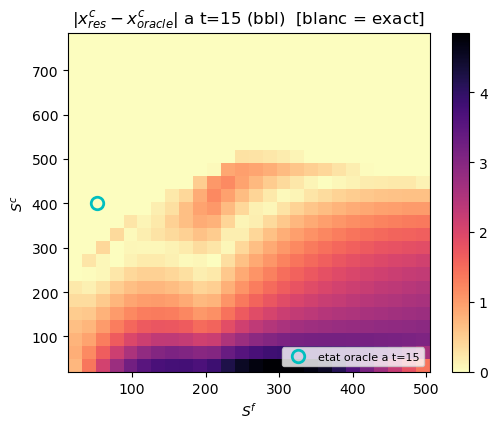

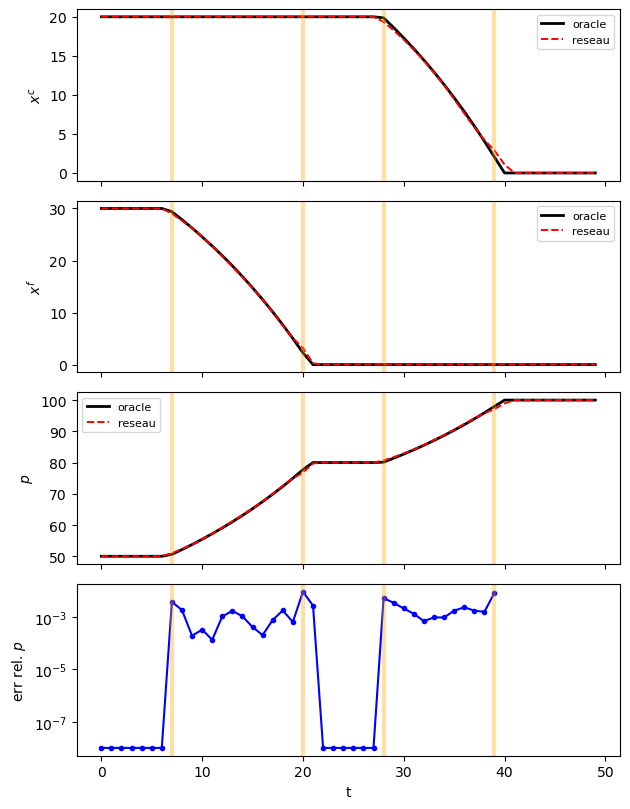

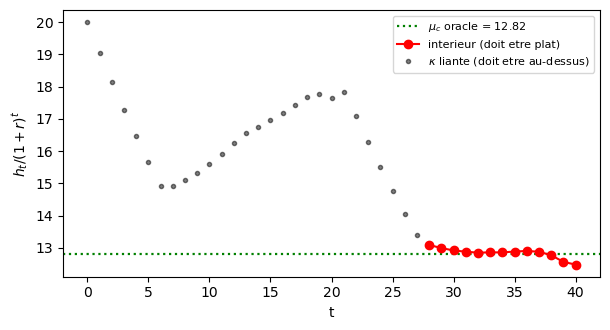


figures -> figs/heatmap_ScSf_M2.png, figs/erreurs_M2.png, figs/hotelling_M2.png, figs/erreur_rente.png (+ .npz)
[E] run logue dans runs.csv (10 lignes)

VALIDATION M2 OK


In [3]:
# M2+ : cartel (strategique) - frange (price-taker), T=50, capacite active, PINN. 
# N=1 strategique => closed-loop = open-loop: on teste notre réseau closed loop contre l'oracle open-loop.

# But : prouver la fiabilite du reseau (rollout <-> oracle) AVANT M3, où l'oracle disparait et le PINN n'aura plus rien d'analytique sur quoi valider (sauf des tests de cohérence: lesquels?)

# MODIFS vs version precedente M2-:
#  - sampler = tube auto-genere (buffer de la politique courante) + petit ancrage uniforme,
#      au lieu du tube-oracle a bruit nul qui privait le rollout sur champ externe
#  - residu de coherence co-etat  dVc/dSc = lambda_c   : interpolation aussi sur
#      le champ de rente
#  - politique  x = min(min(S,kappa), softplus(z)) : touche kappa EXACTEMENT (la sigmoide
#      plafonnait sous kappa, deficit qui amorcait la derive ; cartel cale sur kappa 28/40 dates). Il reste à atteindre la borne inf x=0 exactement (softplus ne le fait pas)
#  - validation : erreur de rollout PAR DATE => verifier qu'elle se localise aux transitions
#      de regime et non partout (ce qui signerait un defaut solveur). Solution: c'est un défaut d'accumulation d'erreur, pas défaut solver majeur


#   torch.tensor.detach()
#   Residu de Sobolev

#+ de notes dans mon cahier et dans ma tête. 


# TOUTES les modifs : le solveur change, l'equilibre attendu NON.
# => l'oracle doit toujours etre retrouvé. 

import os, sys, time, json
import numpy as np
import torch, torch.nn as nn
import torch.nn.functional as F

torch.set_default_dtype(torch.float64)

######## STEP 0  config (pour suivre via des .csv)
CFG = dict(
    tag        = "m2_v3",
    seed       = 0,
    sampler    = "mix",      # "mix" = tube+uniforme (defaut) | "tube_oracle" = bras A/B degrade
    # economie
    alpha=100.0, beta=1.0, cc=10.0, cf=20.0, r=0.05,
    Sc0=700.0, Sf0=450.0, kappa_c=20.0, kappa_f=30.0, T=50,
    # reseau
    width=128, emb_dim=16,
    # loss / sampler
    w_sob=0.5,                 
    env_norm_g=False,           #  normaliser Rc_env/Rf_env par G(t). False = aborté. 
    frac_unif=0.02, box=1.25,
    buf_paths=64, buf_every=50, buf_lo=0.70, buf_hi=1.25,

    #  curriculum retrograde (ENTIÈREMENT ABORTÉ)
    curric=False,
    curric_frac=0.40,          # part des iterations Adam consacree au curriculum (aborté)
    curric_w0=8,               # largeur initiale de la fenetre (dernieres dates)
    curric_unif=0.15,          # ancrage uniforme renforce PENDANT le curriculum : les etats
                               # tardifs du buffer viennent d'une politique encore non entrainee
                               
    # entrainement
    iters=30000, batch=512, lr=1e-3, lbfgs_outer=3,   
    # eval
    snap_eps=1e-4, n_field=200, grid_fig=26,
    t_decouple="20,30,34,38",  # dates du test de decouplage (couvrir kappa ET interieur)
    make_figs=True,
)


for a in sys.argv[1:]:
    if "=" not in a: continue
    k, v = a.split("=", 1)
    if k not in CFG: continue
    CFG[k] = (v.lower() in ("1", "true")) if isinstance(CFG[k], bool) else type(CFG[k])(v)

alpha, beta, cc, cf, r = CFG["alpha"], CFG["beta"], CFG["cc"], CFG["cf"], CFG["r"]
Sc0, Sf0 = CFG["Sc0"], CFG["Sf0"]
kappa_c, kappa_f, T = CFG["kappa_c"], CFG["kappa_f"], CFG["T"]
delta = 1.0/(1.0+r)
VREF = alpha*Sc0                                   # echelles : chaque residu / l'echelle de CE QU'IL MESURE
LREF = alpha                                       # rente bornee par le choke price
XREFC, XREFF = min(kappa_c, Sc0), min(kappa_f, Sf0)
W_SOB, FRAC_UNIF, BOX = CFG["w_sob"], CFG["frac_unif"], CFG["box"]
SNAP_EPS, ENV_G = CFG["snap_eps"], CFG["env_norm_g"]

torch.manual_seed(CFG["seed"]); np.random.seed(CFG["seed"])
S0V = torch.tensor([Sc0, Sf0])                     #  etat de reference, vecteur
KAP = torch.tensor([kappa_c, kappa_f])

def growth_t(ti):
    """G(t) = (1+r)^(t-(T-1)) : vaut 1 a la derniere date de decision, ~0.09 en t=0."""
    return (1.0+r)**(ti.double() - (T-1))

######### STEP 1  oracle


# rentes initiales (mu_c, mu_f), lambda_t = mu*(1+r)^t. A rentes donnees, chaque periode est un
# equilibre STATIQUE a couts effectifs c + lambda_t (gere les coins nativement). Dichotomie sur
# (mu_c, mu_f) pour epuiser les stocks : 2 scalaires au lieu de 2T inconnues et 3^(2T) regimes. 
NITER_BR = 80          # point fixe de best-responses (à la De Cannière): précision machine rapidement atteinte. 

def static_period(ccx, cfx, kapc, kapf):
    xc = np.zeros_like(ccx); xf = np.zeros_like(ccx)
    for _ in range(NITER_BR):
        xc = np.clip((alpha - beta*xf - ccx)/(2*beta), 0.0, kapc)   # cartel : Cournot (xf donne)
        xf = np.clip((alpha - beta*xc - cfx)/beta,     0.0, kapf)   # frange : price-taker
    return xc, xf, alpha - beta*(xc+xf)

def totals(mu_c, mu_f, T_, kapc, kapf):
    g = (1.0+r)**np.arange(T_)
    return static_period(cc + mu_c*g, cf + mu_f*g, np.full(T_, kapc), np.full(T_, kapf))

def solve_oracle(Sc_, Sf_, T_, kapc=None, kapf=None, nbis=60):
    kapc = kappa_c if kapc is None else kapc; kapf = kappa_f if kapf is None else kapf
    def muf(mu_c):
        if totals(mu_c, 0.0, T_, kapc, kapf)[1].sum() <= Sf_: return 0.0
        lo, hi = 0.0, alpha
        for _ in range(nbis):
            m = .5*(lo+hi)
            if totals(mu_c, m, T_, kapc, kapf)[1].sum() > Sf_: lo = m
            else: hi = m
        return .5*(lo+hi)
    if totals(0.0, muf(0.0), T_, kapc, kapf)[0].sum() <= Sc_: mu_c = 0.0
    else:
        lo, hi = 0.0, alpha
        for _ in range(nbis):
            m = .5*(lo+hi)
            if totals(m, muf(m), T_, kapc, kapf)[0].sum() > Sc_: lo = m
            else: hi = m
        mu_c = .5*(lo+hi)
    mf = muf(mu_c); xc, xf, p = totals(mu_c, mf, T_, kapc, kapf)
    return mu_c, mf, xc, xf, p

mu_c_a, mu_f_a, xca, xfa, pa = solve_oracle(Sc0, Sf0, T, nbis=120)

# non-regression M1 (4x4 a T=2 sans capacite) + verites (epuisement, Hotelling interieur)
_xc, _xf = solve_oracle(30.0, 20.0, 2, 1e9, 1e9, nbis=120)[2:4]
_ref = (14.878048780487805, 15.121951219512195, 11.463414634146341, 8.536585365853659)
assert max(abs(_xc[0]-_ref[0]), abs(_xc[1]-_ref[1]), abs(_xf[0]-_ref[2]), abs(_xf[1]-_ref[3])) < 1e-9
assert abs(xca.sum()-Sc0) < 1e-6 and abs(xfa.sum()-Sf0) < 1e-6
_int0 = (xca > 1e-9) & (xca < kappa_c-1e-9)
_hg0 = (pa - beta*xca - cc)/(1.0+r)**np.arange(T)
assert np.allclose(_hg0[_int0], _hg0[_int0].mean(), atol=1e-6)
_tc = int(np.max(np.nonzero(xca > 1e-9)))
print(f"STEP 1 oracle ok : mu=({mu_c_a:.3f},{mu_f_a:.3f}), cartel actif t<={_tc}, "
      f"kappa liante {int((xca>kappa_c-1e-6).sum())}/{T} dates")

SA_T = torch.tensor(np.stack([Sc0 - np.concatenate(([0.], np.cumsum(xca)[:-1])),
                              Sf0 - np.concatenate(([0.], np.cumsum(xfa)[:-1]))], axis=1))  # [T,2]

#####  STEP 2  reseaux


# un reseau par agent, trois tetes (politique z, valeur w, co-etat l), tronc partage
# (coherence topologique : les trois sont des lectures d'une meme representation).
# - ancrage terminal EXACT par 1{t<T} 
# 
# -  embedding de t. SiLU conservé : le residu Sobolev a besoin de dV/dS non trivial, et
#   le kink est deja dans l'architecture via les min() (donc rien a apprendre de non lisse). ReLU pas assez lisse. SiLU asymptotiquement (|x|) = ReLU. 
class Net(nn.Module):
    def __init__(s, width, emb_dim):
        super().__init__()
        s.emb = nn.Embedding(T+1, emb_dim)          # T+1 : l'index t=T existe, neutralise par alive
        nn.init.normal_(s.emb.weight, std=0.1)
        s.trunk = nn.Sequential(nn.Linear(2+emb_dim, width), nn.SiLU(),
                                nn.Linear(width, width), nn.SiLU(),
                                nn.Linear(width, width), nn.SiLU()) # changer le nombre de hidden layers ici, les neurones dans le dictionnaire plus haut. 
                                                                    # 128 neurones et 3 hidden layers, produit les meilleurs résultats pour M2.
        s.head_z = nn.Linear(width, 1); s.head_w = nn.Linear(width, 1); s.head_l = nn.Linear(width, 1)
    def forward(s, S, ti):
        h = s.trunk(torch.cat([S/S0V, s.emb(ti)], dim=-1))
        return s.head_z(h).squeeze(-1), s.head_w(h).squeeze(-1), s.head_l(h).squeeze(-1)

netc, netf = Net(CFG["width"], CFG["emb_dim"]), Net(CFG["width"], CFG["emb_dim"])
PARAMS = list(netc.parameters()) + list(netf.parameters())

def forward_all(S, ti, snap=False):
    """S:[B,2] ti:[B] long -> x:[B,2], Vc:[B], lam:[B,2]"""
    zc, wc, lc_raw = netc(S, ti); zf, _, lf_raw = netf(S, ti)
    # x = min(min(S,kappa), softplus(z)) : atteint kappa EXACTEMENT (coin superieur franc), x>=0.
    x = torch.minimum(torch.minimum(S, KAP),
                      torch.stack([F.softplus(zc), F.softplus(zf)], dim=-1))
    if snap:                                        # [A2] EVAL uniquement (zone morte a l'entrainement)
        x = torch.where(x < SNAP_EPS, torch.zeros_like(x), x)
    alive = (ti < T).double()
    G = growth_t(ti)
    Vc  = alive*wc*VREF
    lam = torch.stack([F.softplus(lc_raw), F.softplus(lf_raw)], dim=-1) * (alive*LREF*G).unsqueeze(-1)
    return x, Vc, lam

#####  STEP 3  residus. C'est incontestablement la STEP la plus IMPORTANTE de tout le code et le réseau.
#####  C'est fiché dans mon cahier: les fonctionnements de clamp() / max() et torch.where() sont subtils mais très très efficaces


# FOC -> politique ; enveloppe -> co-etat ; Bellman -> valeur ; Sobolev -> lie les deux.
def residuals(S, ti):
    S = S.detach().requires_grad_(True)             # [A3] grad sur le VECTEUR d'etat
    x, Vc, lam = forward_all(S, ti)
    xc, xf = x[:, 0], x[:, 1]
    lc, lf = lam[:, 0], lam[:, 1]
    p  = alpha - beta*(xc + xf)
    S2 = S - x                                      # transition (graphe conserve pour M3)
    _, Vc2, lam2 = forward_all(S2, ti+1)
    lc2, lf2 = lam2[:, 0].detach(), lam2[:, 1].detach()
    cap = torch.minimum(S, KAP)

    # h = gain marginal net a extraire un baril de plus ; le clamp encode les coins (0 / kappa).
    hc = p - beta*xc - cc - delta*lc2               # M3: lc2 -> dVc2/dSc2 (autodiff de V)
    Rc_foc = xc - torch.clamp(xc + hc/(2*beta), torch.zeros_like(xc), cap[:, 0])
    hf = p - cf - delta*lf2
    Rf_foc = xf - torch.clamp(xf + hf/beta, torch.zeros_like(xf), cap[:, 1])

    # enveloppe : lambda = max(gain immediat, delta*lambda'). 
    # (a la date de sortie : lambda = max(h,0) = h > 0) ; l'egalite lambda = delta*lambda'
    # ne vaut qu'a l'interieur. 
    bind_c = (xc >= kappa_c - 1e-4).detach()
    tgt_c = torch.where(bind_c, delta*lc2,
                        torch.maximum(p.detach()-beta*xc.detach()-cc, delta*lc2))
    # M3: enveloppe MPE = tgt_c + feedback_c.detach()  (bloc croise ci-dessous)
    Rc_env = lc - tgt_c
    bind_f = (xf >= kappa_f - 1e-4).detach()
    tgt_f = torch.where(bind_f, delta*lf2, torch.maximum(p.detach()-cf, delta*lf2))
    Rf_env = lf - tgt_f                             # frange price-taker : pas de terme croise

    # residu d'enveloppe mesure en unites de mu (constantes sur l'horizon) et non en
    # unites de lambda_t (qui varie d'un facteur 10.8) : sinon les dates precoces, ou lambda
    # est petit, sont sous-ponderees d'un facteur 10 alors qu'elles pilotent le rollout.
    if ENV_G:
        G = growth_t(ti)
        Rc_env = Rc_env/G; Rf_env = Rf_env/G

    Rc_bell = Vc - ((p.detach()-cc)*xc.detach() + delta*Vc2.detach())

    # theoreme de l'enveloppe : contraint la DERIVEE de V entre les points de collocation
    # (Rc_env ~ 0 aux points echantillonnes ne dit rien des derivees entre ces points).
    gV = torch.autograd.grad(Vc.sum(), S, create_graph=True)[0]      # [B,2] gradient complet
    Rc_sob = gV[:, 0] - lc
    # M3: contraindre AUSSI gV[:,1] = dVc/dSf (rien ne l'entraine ici) via le Sobolev-Bellman,
    #     puis : dxf_dS = grad(xf.sum(), S); feedback_c = (-beta*xc - delta*gV2[:,1])*dxf_dS[:,0]
    return Rc_foc, Rc_env, Rc_bell, Rf_foc, Rf_env, Rc_sob



def loss_from_res(R):
    Rc_foc, Rc_env, Rc_bell, Rf_foc, Rf_env, Rc_sob = R
    return ((Rc_foc/XREFC)**2 + (Rc_env/LREF)**2 + (Rc_bell/VREF)**2
            + (Rf_foc/XREFF)**2 + (Rf_env/LREF)**2 + W_SOB*(Rc_sob/LREF)**2).mean()

##### STEP 4  sampler + entrainement : stochastique GD (méthode avancée Adam),  puis L-BFGS (finisseur batch complet)


# tube (buffer de la politique COURANTE : voisinage transverse, force de rappel du rollout)
# + petit ancrage uniforme (structure globale). Le tube-oracle a bruit nul ne donnait aucun
# champ transverse => loss 1e-6 et trajectoire fausse a 16%. 
#### ---> une loss très faible (1e-6) peut cacher une architecture défaillante! on a eu de meilleurs résultats avec une loss finale 1e-4 qu'avec 1e-6. La loss n'est pas un signal à valider.
_BUF = None
def refresh_buffer(n=None):
    
    global _BUF
    n = n or CFG["buf_paths"]
    with torch.no_grad():
        S = (CFG["buf_lo"] + (CFG["buf_hi"]-CFG["buf_lo"])*torch.rand(n, 2))*S0V
        SS, TT = [], []
        for t in range(T):
            ti = torch.full((n,), t, dtype=torch.long)
            SS.append(S.clone()); TT.append(ti)
            x, _, _ = forward_all(S, ti)
            S = S - x
        _BUF = (torch.cat(SS, 0), torch.cat(TT, 0), n)

def t_low(it):
    """[F1] borne basse de la fenetre de dates : part de T-curric_w0, descend vers 0."""
    if not CFG["curric"] or CFG["sampler"] == "tube_oracle": return 0
    n_c = max(1, int(CFG["curric_frac"]*CFG["iters"]))
    if it >= n_c: return 0
    w = CFG["curric_w0"] + (T - CFG["curric_w0"])*(it/n_c)
    return max(0, T - int(round(w)))

def sample_states(B, tlo=0, frac_u=None):
    # le tube est une variété  dans l'hyper-rect d'état (Sc, Sf, t).
    if CFG["sampler"] == "tube_oracle":             # pour la figure A/B
        idx = torch.randint(0, T, (B,))
        return SA_T[idx], idx
    fu = FRAC_UNIF if frac_u is None else frac_u
    n_u = int(fu*B); n_b = B - n_u
    S_u = torch.rand(n_u, 2)*S0V*BOX
    t_u = torch.randint(tlo, T, (n_u,))
    n = _BUF[2]
    idx = torch.randint(tlo*n, T*n, (n_b,))         
    return torch.cat([S_u, _BUF[0][idx]], 0), torch.cat([t_u, _BUF[1][idx]], 0)

print(f"STEP 4 : Adam (sampler={CFG['sampler']}, curric={CFG['curric']}, env_norm_g={ENV_G})...")
opt = torch.optim.Adam(PARAMS, lr=CFG["lr"])
t0 = time.time(); refresh_buffer(); loss_hist = []
n_curric = max(1, int(CFG["curric_frac"]*CFG["iters"]))
for it in range(CFG["iters"]):
    if it == CFG["iters"]*4//10:
        for g in opt.param_groups: g["lr"] = 3e-4
    if it == CFG["iters"]*6//10:
        for g in opt.param_groups: g["lr"] = 1e-4
    if CFG["sampler"] == "mix" and it % CFG["buf_every"] == 0: refresh_buffer()
    tlo = t_low(it)
    
    fu = CFG["curric_unif"] if (CFG["curric"] and it < n_curric) else None
    opt.zero_grad()
    L = loss_from_res(residuals(*sample_states(CFG["batch"], tlo, fu)))
    L.backward(); opt.step()
    if it % 100 == 0: loss_hist.append((it, L.item(), tlo))
    if it % 3000 == 0:
        print(f"  it={it:5d} loss={L.item():.3e} [dates {tlo}..{T-1}] ({time.time()-t0:.0f}s)", flush=True)

print("STEP 4 : L-BFGS (collocation fixe, fenetre complete)...")

# Méthode quasi-Newton optimisée, qui stocke l'historique ici des 60 dernières paires (pas,changement de gradient)
# pour mieux suivre la courbe de la loss
# L-BFGS vient préciser la direction par rapport à Adam au fond des puits, elle ne le remplace pas
for outer in range(CFG["lbfgs_outer"]):
    if CFG["sampler"] == "mix": refresh_buffer(256)
    Sb, tb = sample_states(6000, 0)                 # finisseur : toujours toutes les dates
    Sb = torch.cat([Sb, S0V.expand(100, 2)], 0)     # ancre S0 dans le jeu fixe
    tb = torch.cat([tb, torch.zeros(100, dtype=torch.long)], 0)
    opt2 = torch.optim.LBFGS(PARAMS, lr=1.0, max_iter=400, history_size=60,
                             tolerance_grad=1e-15, tolerance_change=1e-16,
                             line_search_fn="strong_wolfe")
    def closure():
        opt2.zero_grad(); Lf = loss_from_res(residuals(Sb, tb)); Lf.backward(); return Lf
    L = opt2.step(closure)
    loss_hist.append((CFG["iters"]+outer, L.item(), 0))
    print(f"  outer={outer} loss={L.item():.3e} ({time.time()-t0:.0f}s)", flush=True)
LOSS_FINAL = L.item()

###### STEP 5  rollout vs oracle (rollout=déroulement de t=0 jusqu'à t=50 en appellant la fonction sigma du réseau itérativement)


def rollout(S_init, snap=True):
    S = S_init.clone().reshape(1, 2); X, P = [], []
    with torch.no_grad():
        for t in range(T):
            x, _, _ = forward_all(S, torch.tensor([t]), snap=snap)
            X.append(x[0].clone().numpy()); P.append((alpha - beta*x.sum()).item())
            S = S - x
    return np.array(X), np.array(P), S[0].numpy()

X, P, Send = rollout(S0V)
XC, XF = X[:, 0], X[:, 1]
act = xca > 1e-6
err_xc = np.abs(XC[act]-xca[act]).max()/xca.max()
err_p  = np.abs(P[act]-pa[act]).max()/pa.max()
print("\n t  | reseau (xc,xf,p)          | oracle (xc,xf,p)")
for tt in [time for time in range(0,T,1)]:#[0, 10, 20, 30, _tc, 45]:
    print(f" {tt:3d}| ({XC[tt]:6.2f},{XF[tt]:6.2f},{P[tt]:6.2f}) | ({xca[tt]:6.2f},{xfa[tt]:6.2f},{pa[tt]:6.2f})")
print(f"epuisement {XC.sum():.1f}/{Sc0}, {XF.sum():.1f}/{Sf0} | err_max(actives) xc={err_xc:.2e} p={err_p:.2e}")

ep = np.abs(P[act]-pa[act])/pa.max(); ia = np.nonzero(act)[0]
top = np.argsort(ep)[::-1][:4]
print("   4 pires dates :", ", ".join(f"t={ia[i]}({ep[i]*100:.1f}%)" for i in top))

#  Hotelling : marge STRATEGIQUE h = p - beta*x_c - c_c 
# A l'interieur h = lambda_t = mu_c(1+r)^t : la courbe deflatee doit etre PLATE, ET a la hauteur mu_c.
m_int = (XC > 1e-3) & (XC < kappa_c-1e-3)
hall = (P - beta*XC - cc)/(1.0+r)**np.arange(T)
hg = hall[m_int]
HOT_CV = hg.std()/abs(hg.mean()) if m_int.sum() > 1 else np.nan
HOT_LVL = abs(hg.mean()-mu_c_a)/mu_c_a if m_int.sum() > 0 else np.nan
print(f"   Hotelling rollout : cv={HOT_CV:.2e} sur {int(m_int.sum())} dates | "
      f"niveau {hg.mean():.2f} vs mu_c={mu_c_a:.2f} (ecart {HOT_LVL:.2%})")

###### STEP 5a  rente par date


lam_true = mu_c_a*(1.0+r)**np.arange(T)
with torch.no_grad():
    _, _, lam_net = forward_all(SA_T, torch.arange(T))
lam_net_c = lam_net[:, 0].numpy()
rel_lam = np.abs(lam_net_c-lam_true)/np.maximum(lam_true, 1e-9)
LAM_MED = float(np.median(rel_lam[act])); LAM_MAX = float(rel_lam[act].max())
print(f"\nSTEP 5a rente le long du sentier : err rel mediane {LAM_MED:.2%}, max {LAM_MAX:.2%} "
      f"(a t={int(ia[np.argmax(rel_lam[act])])})")
print("   " + " ".join(f"t{t}:{rel_lam[t]*100:.1f}%" for t in (0, 10, 20, 30, 34, 39)))

###### STEP 5b  champ, STRATIFIE


# attention médiane globale peut cacher des errerus (erreur strictmeent nulle à précision machine aux coins supérieurs)

rng = np.random.default_rng(0); nf = CFG["n_field"]
scf = rng.uniform(0.05, 1.10, nf)*Sc0; sff = rng.uniform(0.05, 1.10, nf)*Sf0
tf  = rng.integers(0, T-1, nf)
rows = []
with torch.no_grad():
    for scv, sfv, tv in zip(scf, sff, tf):
        mc, _, xco, _, _ = solve_oracle(scv, sfv, T-int(tv), nbis=40)
        xn, _, ln = forward_all(torch.tensor([[scv, sfv]]), torch.tensor([int(tv)]), snap=True)
        reg = "kappa" if xco[0] >= kappa_c-1e-6 else ("zero" if xco[0] <= 1e-9 else "interieur")
        rows.append((reg, abs(xn[0, 0].item()-xco[0]), abs(ln[0, 0].item()-mc)))
print("\nSTEP 5b champ (oracle tronque), par regime :")
FIELD = {}
for reg in ("kappa", "interieur", "zero"):
    d = [(a, b) for g, a, b in rows if g == reg]
    if not d: continue
    pol = np.array([u[0] for u in d]); lam = np.array([u[1] for u in d])
    FIELD[reg] = (np.median(pol), np.quantile(pol, .9), np.median(lam), np.quantile(lam, .9))
    print(f"  {reg:9s} n={len(d):3d} | politique med {np.median(pol):.3f} q90 {np.quantile(pol,.9):.3f} bbl"
          f" | rente med {np.median(lam):.2f} q90 {np.quantile(lam,.9):.2f} $/bbl")
FIELD_INT = FIELD.get("interieur", (np.nan,)*4)

###### STEP 5c  recuperation hors-sentier


# le test qui distingue une POLITIQUE sigma(S) d'une sequence memorisee : partir d'ailleurs et
# retomber sur l'oracle recalcule depuis ce point. 0.8 (franchement interieur) ET 1.2 (bord de boite).
print("\nSTEP 5c recuperation hors-sentier")
REC = {}
for fac in (0.8, 1.2):
    Xp, Pp, _ = rollout(S0V*fac)
    _, _, xco, xfo, po = solve_oracle(Sc0*fac, Sf0*fac, T, nbis=120)
    a = xco > 1e-6
    REC[fac] = np.abs(Pp[a]-po[a]).max()/po.max()
    print(f"  S0x{fac} : err_p={REC[fac]:.2e}  (epuisement {Xp[:,0].sum():.0f}/{Sc0*fac:.0f})")

####### STEP 5d 


# action du reseau A L'ETAT ORACLE de la date t, puis continuation ORACLE.


print("\nSTEP 5d decouplage 1-pas (etat oracle) :")
DEC = {}
for tstar in [int(u) for u in CFG["t_decouple"].split(",")]:
    if tstar >= _tc: continue
    Sst = SA_T[tstar].reshape(1, 2)
    with torch.no_grad():
        xs, _, _ = forward_all(Sst, torch.tensor([tstar]), snap=True)
    xs = xs[0].numpy()
    _, _, _, _, ptail = solve_oracle(Sst[0, 0].item()-xs[0], Sst[0, 1].item()-xs[1],
                                     T-tstar-1, nbis=120)
    ph = np.concatenate(([alpha - beta*xs.sum()], ptail))
    ao = xca[tstar:] > 1e-6
    DEC[tstar] = float(np.abs(ph[ao]-pa[tstar:][ao]).max()/pa.max())
    reg = "kappa" if xca[tstar] >= kappa_c-1e-6 else "interieur"
    print(f"  t={tstar:2d} ({reg:9s}) : err_p={DEC[tstar]:.2e}")

####### STEP 6  Bellman Monte-Carlo


# coherence de la VALEUR 
with torch.no_grad():
    _, V0, _ = forward_all(S0V.reshape(1, 2), torch.tensor([0]))
V_net = V0.item(); V_mc = float(np.sum(delta**np.arange(T)*(P - cc)*XC))
print(f"\nSTEP 6 Bellman MC : V_net={V_net:.1f} vs profit realise={V_mc:.1f}  "
      f"ecart {abs(V_net-V_mc)/max(abs(V_mc),1e-9):.2%}")

####### STEP 7  enveloppe + gradient croisé

Sp = (torch.rand(2000, 2)*S0V*1.1).requires_grad_(True)
tp = torch.randint(0, T-1, (2000,))
_, Vp, lamp = forward_all(Sp, tp)
gV = torch.autograd.grad(Vp.sum(), Sp)[0]
COH = ((gV[:, 0]-lamp[:, 0]).abs()/(lamp[:, 0].abs()+1e-6)).median().item()
CROSS_NEG = (gV[:, 1] < 0).double().mean().item()
print(f"STEP 7 enveloppe |dVc/dSc - lambda|/lambda = {COH:.2%}  (<1% => tete lambda supprimable a M3)")
print(f"        dVc/dSf < 0 sur {CROSS_NEG:.0%} des etats  (attendu ~100% ; sinon Sobolev croise requis)")
###### figures
if CFG["make_figs"]:
    try:
        import matplotlib.pyplot as plt
        os.makedirs("figs", exist_ok=True); tag = CFG["tag"]

        # heatmap du champ : |x_reseau - x_oracle| sur une coupe (Sc,Sf) a t fixe.
        # L'argument du PINN : le tir donne UNE trajectoire, le reseau donne la politique PARTOUT( le reseau donne la fonction sigma(S,t))
        tfix = 15; G_ = CFG["grid_fig"]
        gc = np.linspace(0.05, 1.10, G_)*Sc0; gf = np.linspace(0.05, 1.10, G_)*Sf0
        Z = np.zeros((G_, G_))
        for i, a_ in enumerate(gc):
            for j, b_ in enumerate(gf):
                _, _, xo, _, _ = solve_oracle(a_, b_, T-tfix, nbis=30)
                with torch.no_grad():
                    xn, _, _ = forward_all(torch.tensor([[a_, b_]]), torch.tensor([tfix]), snap=True)
                Z[i, j] = abs(xn[0, 0].item()-xo[0])
        fig, ax = plt.subplots(figsize=(5.4, 4.4))
        im = ax.pcolormesh(gf, gc, Z, shading="auto", cmap="magma_r")
        # le point du sentier A CETTE DATE (et non le sentier entier : la coupe est a t figé)
        ax.plot(SA_T[tfix, 1].item(), SA_T[tfix, 0].item(), "co", ms=9, mew=2, mfc="none",
                label=f"etat oracle a t={tfix}")
        ax.set_xlabel("$S^f$"); ax.set_ylabel("$S^c$")
        ax.set_title(f"|$x^c_{{res}}-x^c_{{oracle}}$| a t={tfix} (bbl)  [blanc = exact]")
        ax.legend(loc="lower right", fontsize=8)
        fig.colorbar(im, ax=ax); fig.tight_layout(); fig.savefig("figs/heatmap_ScSf_M2.png", dpi=160)

        # rollout vs oracle + erreur par date (log) 
        fig, axs = plt.subplots(4, 1, figsize=(6.4, 8.2), sharex=True)
        for k, (nn_, oo, lab) in enumerate([(XC, xca, "$x^c$"), (XF, xfa, "$x^f$"), (P, pa, "$p$")]):
            axs[k].plot(oo, "k-", lw=2, label="oracle"); axs[k].plot(nn_, "r--", lw=1.4, label="reseau")
            axs[k].set_ylabel(lab); axs[k].legend(fontsize=8)
        axs[3].semilogy(ia, np.maximum(ep, 1e-8), "b.-"); axs[3].set_ylabel("err rel. $p$")
        for tt in ia[top]:
            for a_ in axs: a_.axvline(tt, color="orange", alpha=.35, lw=3)
        axs[3].set_xlabel("t"); fig.tight_layout(); fig.savefig("figs/erreurs_M2.png", dpi=160)

        # Hotelling : plat A LA HAUTEUR mu_c a l'interieur ; les dates saturees sont AU-DESSUS
        fig, ax = plt.subplots(figsize=(6.2, 3.4))
        ax.axhline(mu_c_a, color="g", ls=":", lw=1.6, label=f"$\\mu_c$ oracle = {mu_c_a:.2f}")
        ax.plot(np.arange(T)[m_int], hall[m_int], "ro-", label="interieur (doit etre plat)")
        ax.plot(np.arange(T)[~m_int & act], hall[~m_int & act], "k.", alpha=.5,
                label="$\\kappa$ liante (doit etre au-dessus)")
        ax.set_xlabel("t"); ax.set_ylabel("$h_t/(1+r)^t$"); ax.legend(fontsize=8)
        fig.tight_layout(); fig.savefig("figs/hotelling_M2.png", dpi=160)

        # # rente par date : le diagnostic du maillon faible
        # fig, ax = plt.subplots(figsize=(6.2, 3.4))
        # ax.semilogy(ia, np.maximum(rel_lam[act], 1e-6), "m.-")
        # kap_d = np.nonzero(act & (xca >= kappa_c-1e-6))[0]
        # ax.plot(kap_d, np.maximum(rel_lam[kap_d], 1e-6), "ks", ms=4, label="$\\kappa$ liante")
        # ax.set_xlabel("t"); ax.set_ylabel("err rel. $\\lambda_c$"); ax.legend(fontsize=8)
        # ax.set_title("erreur de rente le long du sentier (vs $\\mu_c(1+r)^t$)")
        # fig.tight_layout(); fig.savefig("figs/erreur_rente.png", dpi=160)

        np.savez(f"figs/{tag}_curves.npz", loss=np.array(loss_hist), XC=XC, XF=XF, P=P,
                 xca=xca, xfa=xfa, pa=pa, err_p=err_p, rel_lam=rel_lam)
        
        plt.show()
        print("\nfigures -> figs/heatmap_ScSf_M2.png, figs/erreurs_M2.png, figs/hotelling_M2.png, figs/erreur_rente.png (+ .npz)")
    except Exception as e:
        print(f"\n[figures ignorees : {e}]")

##### log CSV


row = dict(CFG)
row.update(run_id=time.strftime("%Y%m%d-%H%M%S"), secs=round(time.time()-t0),
           loss=LOSS_FINAL, err_p=err_p, err_xc=err_xc, hot_cv=HOT_CV, hot_lvl=HOT_LVL,
           lam_path_med=LAM_MED, lam_path_max=LAM_MAX,
           field_int_pol_med=FIELD_INT[0], field_int_pol_q90=FIELD_INT[1],
           field_int_lam_med=FIELD_INT[2], field_int_lam_q90=FIELD_INT[3],
           rec_08=REC[0.8], rec_12=REC[1.2],
           bellman_gap=abs(V_net-V_mc)/max(abs(V_mc), 1e-9), coh=COH, cross_neg=CROSS_NEG,
           cum_c=XC.sum(), cum_f=XF.sum())
row.update({f"dec_t{k}": v for k, v in DEC.items()})
try:
    import pandas as pd
    p_csv = "runs.csv"
    df = pd.DataFrame([row])
    if os.path.exists(p_csv): df = pd.concat([pd.read_csv(p_csv), df], ignore_index=True)
    df.to_csv(p_csv, index=False)
    print(f"[E] run logue dans {p_csv} ({len(df)} lignes)")
except Exception as e:
    print(f"[E] pandas indisponible ({e}) ; ligne brute :\n{json.dumps(row, default=str)}")

assert err_p < 5e-2, f"rollout prix trop loin de l'oracle : {err_p:.2e}"
print("\nVALIDATION M2 OK" if err_p < 1e-2 else f"\ntolerance large ; err_p={err_p:.2e} > 1%")


# Résultats M2+, discussions


* méthode de l'oracle: shooting method (pour la rente) et méthode du point-fixe type De Cannière (pour les extractions). Shooting method= réduire un programme intertemporel en recherche de conditions initiales seulement (car la rente évolue selon mu_i*(1+r)^t)
* épuisement parfait (V(.,T)=0 mais le réseau n'a aucune contrainte l'obligeant à vider le stock type contrainte intégrale). L'extraction cartel tombe à zéro de manière endogène à t=39.
C'est bon signe et sain pour la rente; néanmoins une Une erreur de 3% sur $\lambda$  signifie que le réseau extrait légèrement trop à certaines dates et compense ce déficit à d'autres pour vider la réserve. C'est $\alpha$ qui joue le rôle de Backstop.  
* règle de Hotelling (courbe rouge) : Valeur Présente du revenu marginal net. En régime intérieur (zone rouge de la courbe) h_t doit croître selon $\mu_c (1+r)^t$. Légère diminution après la fin du régime intérieur: attribuable à softplus(z) qui ne fait pas exactement zéro. Le réseau prédit des valeurs résiduelles très faibles, mais supérieures au seuil naïf 10e-3.   En cours de correction.  
La courbe m'a permis de relever cet artefact ($\uparrow$). C'est dans les TODO immédiats ($\downarrow$)

* Tête valeur saine : $V(S_0,0)$ = intégration Monte Carlo de Profit = $\sum_t (p-c)x$. Cela prouve que l'équation récursive locale de Bellman $R_{\text{bell}} = V_t - (\pi_t + \delta V_{t+1}) = 0$ a formellement convergé.
* Preuve du MPE: récupération hors-sentier et qualité d'interpolation. Pas besoin d'aller chercher des stocks très lointains et inatteignables physiquement & économiquement. 
* résidu d'autodifférentiation : distance entre grad(V) et lambda, MAPE 1.78%
Autodiff (autograd): PyTorch construit silencieusement un graphe orienté acyclique mémorisant chaque opération élémentaire et ses arguments lors du forward pass. Lors de torch.autograd.grad, le moteur remonte ce graphe à l'envers, il n'a qu'à appliquer les termes mémorisés. 
-> Voir docu PyTorch, ficher dans cahier. 
* dVc/dSf < 0 sur 98% des états 
### résultats STEP5 du code: quelques sanity checks. 
- step 5b: la gestion des cocntraintes de capacité est parfaite et exacte; erreur strictement nulle au coin supérieur. L'erreur vient du régime intérieur (de l'ordre de 4%, 1 bbl au maximum, échelle 20)
- step 5c: preuve que le réseau approxime bien l'équilibre de Markov. Voir heatmap aussi. 
- step 5d: découplage erreur systématique (=faille de l'architecture) VS accumulation d'erreur d'approximation (0.3% sur le prix environ sur 1 pas)


Quelques commentaires donc:  
* erreurs très localisées aux kinks (=changements de régimes)
* erreur strictement nulle aux coins supérieurs (kappa) (il suffit que softplus(z)≥$\kappa$).
* erreur sur la rente = le bottleneck. Elle se propage via les FOC et contamine la politique fournie par le réseau. Les résidus d'autodifférentiation de la fonction valeur pour donner la rente seront implémentées à M3; cela pourrait diminuer les erreurs.  
* néanmoins, le comportement global de la rente est tout à fait cohérent et précis (voir courbe). Le comportement est celui attendu au coin supérieur (oscillation de la courbe grise) et au régime intérieur (courbe rouge plate); toutefois le réseau peine à ordonner x= zéro pur à cause de x=0 pur à cause de $x \propto \text{softplus}(z) = \ln(1+\exp(z))$. qui doit pousser la tête z vers -infty pour produire x=0. Work in progress. 
* heatmap: zone sombre physiquement inatteignables (stock cartel faible prématurément: il faudrait que le cartel puisse extraire massivement aux premières périodes, impossible par les contraintes de capacité). On pourrait essayer de les éclaircir en augmentant FRAC_UNIF mais on risque de dégrader les zones normales. C'est inoffensif pour le PINN. Bref: le réseau se trompe lourdement sur des zones qu'il n'aura de toute façon jamais à essayer de prédire. 


#### Reste à faire pour M2 (en cours, M3 en cours aussi): 
* L-BFGS: à essayer outer, max_iter, supprimer L-BFGS, allonger L-BFGS. 
* bruit multi-seed: pour quantifier le bruit du solver; pour que plus tard on dissocie le bruit du solver de l'erreur systématique. 
* sampler A/B: tube parfait vs tube+unif
* améliorer le réseau pour gérer les coins inférieurs x=0. 


# Vers M3
* je travaille sur la généralisation à N joueurs. C'est la transition la plus complexe, et l'une des dernières transitions (avec masque qui décide si la FOC=oligopoliste,cartelliste, ou frange)




* Structure {cartellistes, oligopolistes, frange, partenaires coalition}. Masque: 
$$h_i = p - \beta \Lambda_i - c_i - \delta \lambda_i' \quad \text{avec} \quad \Lambda_i = \begin{cases} Q^C = \sum_{j \in C} x_j & \text{si } i \in C \\ x_i & \text{si } i \in O \\ 0 & \text{frange} \end{cases}$$